# Stress-testing an income classifier on the Adult Census data

- **Author:** Sanskar Awasthi
- **Dataset:** Adult Census Income (UCI)
- **Random seed:** 138, 70/30 train-test split

This notebook produces every number, table and chart that appears in my PDF report. To reproduce it, run it from top to bottom (Kernel > Restart & Run All). It downloads the data if the `data/` folder is empty. Tables are saved to `outputs/tables/`, figures to `outputs/figures/`, and the headline numbers to `outputs/key_numbers.json`.

Contents:

0. Loading the data
1. Preprocessing (missing values, encoding, outliers, scaling)
2. Part 1: Model A (OLS) vs Model B (logistic regression)
3. Part 2.1: Simpson's paradox
4. Part 2.2: Omitted-variable bias
5. Part 2.3: Adversarial subset
6. Part 2.4: Fairness trade-offs
7. Extra checks used in the written answers

In [1]:
import json
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, r2_score, mean_squared_error

SEED = 138
DATA_DIR = Path("data")
FIG_DIR = Path("outputs/figures")
TAB_DIR = Path("outputs/tables")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
FEMALE_C, MALE_C = "#c0392b", "#2c6fbb"

# every number I quote in the report gets stored here and saved at the end
key = {}

## 0. Loading the data

UCI ships Adult as two files: `adult.data` (32,561 rows) and `adult.test` (16,281 rows). I want my own 70/30 split with seed 138, so I stack both files and split them again myself.

In [2]:
COLS = ["age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
        "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
        "hours_per_week", "native_country", "income"]
BASE_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/"

DATA_DIR.mkdir(exist_ok=True)
for name in ["adult.data", "adult.test"]:
    if not (DATA_DIR / name).exists():
        urllib.request.urlretrieve(BASE_URL + name, DATA_DIR / name)

# '?' is how this dataset marks a missing value. adult.test has a junk first line.
read_opts = dict(header=None, names=COLS, skipinitialspace=True, na_values="?")
part1 = pd.read_csv(DATA_DIR / "adult.data", **read_opts)
part2 = pd.read_csv(DATA_DIR / "adult.test", skiprows=1, **read_opts)
raw = pd.concat([part1, part2], ignore_index=True)

# labels in adult.test end with a full stop (">50K."), so remove it
raw["income"] = raw["income"].str.rstrip(".")

key["n_raw"] = len(raw)
print(raw.shape)
print(raw["income"].value_counts())
raw.head()

(48842, 15)
income
<=50K    37155
>50K     11687
Name: count, dtype: int64


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 1. Data preprocessing

### 1.1 Missing values and duplicates

In [3]:
missing = raw.isna().sum()
missing = missing[missing > 0].to_frame("n_missing")
missing["pct_of_rows"] = (missing["n_missing"] / len(raw) * 100).round(2)
print(missing, "\n")

any_missing = raw[["workclass", "occupation", "native_country"]].isna().any(axis=1)
rich = raw["income"].eq(">50K")
print(f"rows with at least one missing value: {any_missing.sum()} ({any_missing.mean():.1%})")
print(f">50K rate in rows with a missing value: {rich[any_missing].mean():.3f}")
print(f">50K rate in complete rows:             {rich[~any_missing].mean():.3f}\n")

# workclass and occupation go missing together
both = raw["workclass"].isna() & raw["occupation"].isna()
print("workclass missing:", raw["workclass"].isna().sum(),
      "| occupation missing:", raw["occupation"].isna().sum(), "| both:", both.sum())
print("workclass of the rows where only occupation is missing:")
print(raw.loc[raw["occupation"].isna() & raw["workclass"].notna(), "workclass"].value_counts(), "\n")

print("exact duplicate rows:", raw.duplicated().sum())

missing.to_csv(TAB_DIR / "prep_missing_values.csv")
key["missing_workclass"] = int(raw["workclass"].isna().sum())
key["missing_occupation"] = int(raw["occupation"].isna().sum())
key["missing_country"] = int(raw["native_country"].isna().sum())
key["missing_both_job"] = int(both.sum())
key["rows_any_missing"] = int(any_missing.sum())
key["pct_rows_any_missing"] = round(any_missing.mean() * 100, 2)
key["rich_rate_missing_rows"] = round(rich[any_missing].mean(), 3)
key["rich_rate_complete_rows"] = round(rich[~any_missing].mean(), 3)
key["n_duplicates"] = int(raw.duplicated().sum())

                n_missing  pct_of_rows
workclass            2799         5.73
occupation           2809         5.75
native_country        857         1.75 

rows with at least one missing value: 3620 (7.4%)
>50K rate in rows with a missing value: 0.132
>50K rate in complete rows:             0.248

workclass missing: 2799 | occupation missing: 2809 | both: 2799
workclass of the rows where only occupation is missing:
workclass
Never-worked    10
Name: count, dtype: int64 

exact duplicate rows: 52


**What I did about missing values.** About 7.4% of rows have a `?` somewhere, nearly all in `workclass` and `occupation` (which go missing together) and a few in `native_country`. These rows are not missing completely at random: only 13.2% of them earn >50K, compared with 24.8% of complete rows. If I deleted them, I would be removing a poorer group and nudging the base rate up. So I keep them:

* the missing value is filled with the most common category in the **training** set (mode imputation), and
* a 0/1 flag records that the value was missing (`job_missing` for workclass/occupation, `country_missing` for native country), so the model can still learn that "missing" behaves differently.

I use one flag for workclass and occupation instead of two because they are missing on almost exactly the same rows, so two separate "Unknown" dummies would be almost perfectly collinear. My first version did exactly that and the logit did not converge. Section 1.6 rebuilds that first attempt to show the problem.

The 52 exact duplicate rows are dropped.

### 1.2 Columns I leave out of the model

In [4]:
# relationship is mostly marital status crossed with sex
print(pd.crosstab(raw["relationship"], raw["sex"]), "\n")

# education and education_num carry the same information
print("distinct education labels per education_num value:",
      raw.groupby("education_num")["education"].nunique().max())

sex             Female   Male
relationship                 
Husband              1  19715
Not-in-family     5870   6713
Other-relative     689    817
Own-child         3376   4205
Unmarried         3928   1197
Wife              2328      3 

distinct education labels per education_num value: 1


* `fnlwgt` is the Census sampling weight. It says how many people a row stands for in the population, not anything about the person, so it is not a sensible predictor.
* `education` is the text version of `education_num` (one label per number), so I keep only the numeric one.
* `relationship` is basically marital status crossed with sex: "Husband" is 19,715 men and 1 woman, "Wife" is 2,328 women and 3 men. With `sex` and `marital_status` already in the model it adds near-collinearity and makes the sex coefficient hard to read. I keep the column in the data frame (it is used once, in Section 7, as a residual check) but never as a feature.

### 1.3 Cleaning and grouping categories

In [5]:
df = raw.drop_duplicates().reset_index(drop=True)
df["y"] = (df["income"] == ">50K").astype(int)

# missing-value flags are created before anything is filled in
df["job_missing"] = df["occupation"].isna().astype(int)
df["country_missing"] = df["native_country"].isna().astype(int)

# merge categories that are too small to get a stable coefficient
df["workclass"] = df["workclass"].replace({
    "Federal-gov": "Government", "Local-gov": "Government", "State-gov": "Government",
    "Never-worked": "No-pay", "Without-pay": "No-pay",
})
df["occupation"] = df["occupation"].replace({"Armed-Forces": "Protective-serv"})
df["marital_status"] = df["marital_status"].replace({
    "Married-civ-spouse": "Married", "Married-AF-spouse": "Married",
    "Divorced": "Div-Sep", "Separated": "Div-Sep", "Married-spouse-absent": "Div-Sep",
})
# 41 countries, most with only a few dozen people, so US vs everyone else
df["native_country"] = df["native_country"].map(
    lambda c: c if pd.isna(c) else ("US" if c == "United-States" else "Non-US"))

key["n_clean"] = len(df)
key["base_rate_all"] = round(df["y"].mean(), 4)
print(len(df), "rows after dropping duplicates")
for col in ["workclass", "marital_status", "occupation", "race", "sex", "native_country"]:
    print(df[col].value_counts(dropna=False).to_dict())

48790 rows after dropping duplicates
{'Private': 33860, 'Government': 6549, 'Self-emp-not-inc': 3861, nan: 2795, 'Self-emp-inc': 1694, 'No-pay': 31}
{'Married': 22403, 'Never-married': 16082, 'Div-Sep': 8787, 'Widowed': 1518}
{'Prof-specialty': 6165, 'Craft-repair': 6102, 'Exec-managerial': 6082, 'Adm-clerical': 5606, 'Sales': 5501, 'Other-service': 4919, 'Machine-op-inspct': 3017, nan: 2805, 'Transport-moving': 2355, 'Handlers-cleaners': 2071, 'Farming-fishing': 1485, 'Tech-support': 1445, 'Protective-serv': 997, 'Priv-house-serv': 240}
{'White': 41714, 'Black': 4683, 'Asian-Pac-Islander': 1517, 'Amer-Indian-Eskimo': 470, 'Other': 406}
{'Male': 32614, 'Female': 16176}
{'US': 43792, 'Non-US': 4142, nan: 856}


### 1.4 Outliers

                  count     mean      std   min   25%   50%   75%      max
age             48790.0    38.65    13.71  17.0  28.0  37.0  48.0     90.0
education_num   48790.0    10.08     2.57   1.0   9.0  10.0  12.0     16.0
hours_per_week  48790.0    40.43    12.39   1.0  40.0  40.0  45.0     99.0
capital_gain    48790.0  1080.22  7455.91   0.0   0.0   0.0   0.0  99999.0
capital_loss    48790.0    87.60   403.21   0.0   0.0   0.0   0.0   4356.0 

rows outside the 1.5*IQR fences:
 age                 215
education_num      1787
hours_per_week    13486
capital_gain       4035
capital_loss       2282
dtype: int64 

fences (low, high):
                  low  high
age             -2.0  78.0
education_num    4.5  16.5
hours_per_week  32.5  52.5
capital_gain     0.0   0.0
capital_loss     0.0   0.0 

capital_gain is 0 for 91.7% of rows, and exactly 99999 (top code) for 244 rows
capital_loss is 0 for 95.3% of rows
age == 90: 54 | hours_per_week == 99: 137


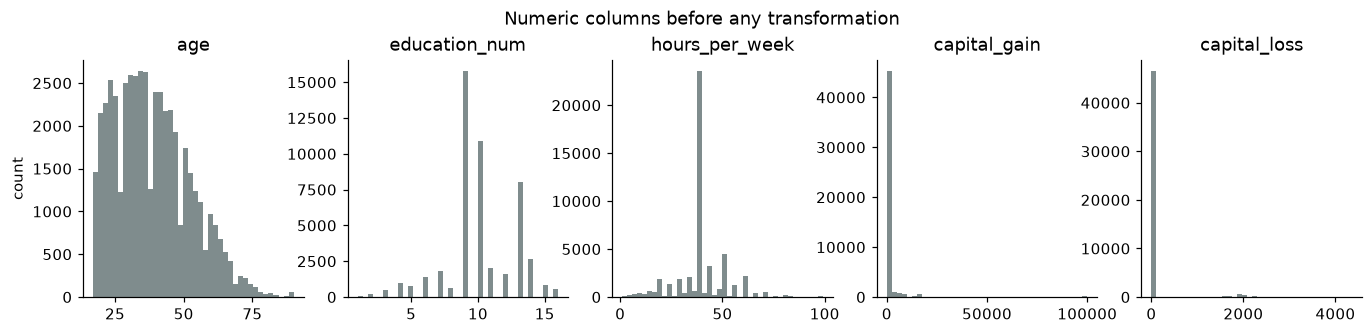

In [6]:
NUM_COLS = ["age", "education_num", "hours_per_week", "capital_gain", "capital_loss"]
print(df[NUM_COLS].describe().T.round(2), "\n")

q1, q3 = df[NUM_COLS].quantile(0.25), df[NUM_COLS].quantile(0.75)
iqr = q3 - q1
iqr_flags = ((df[NUM_COLS] < q1 - 1.5 * iqr) | (df[NUM_COLS] > q3 + 1.5 * iqr)).sum()
print("rows outside the 1.5*IQR fences:\n", iqr_flags, "\n")
print("fences (low, high):\n", pd.DataFrame({"low": q1 - 1.5 * iqr, "high": q3 + 1.5 * iqr}), "\n")

print(f"capital_gain is 0 for {(df.capital_gain == 0).mean():.1%} of rows, "
      f"and exactly 99999 (top code) for {(df.capital_gain == 99999).sum()} rows")
print(f"capital_loss is 0 for {(df.capital_loss == 0).mean():.1%} of rows")
print("age == 90:", (df.age == 90).sum(), "| hours_per_week == 99:", (df.hours_per_week == 99).sum())

outlier_tab = pd.DataFrame({"iqr_outliers": iqr_flags,
                            "pct": (iqr_flags / len(df) * 100).round(2)})
outlier_tab.to_csv(TAB_DIR / "prep_outliers_iqr.csv")
key["cg_zero_pct"] = round((df.capital_gain == 0).mean() * 100, 1)
key["cl_zero_pct"] = round((df.capital_loss == 0).mean() * 100, 1)
key["cg_99999"] = int((df.capital_gain == 99999).sum())
key["iqr_hours"] = int(iqr_flags["hours_per_week"])
key["iqr_age"] = int(iqr_flags["age"])
key["iqr_edu"] = int(iqr_flags["education_num"])
key["iqr_age_fence_high"] = float(q3["age"] + 1.5 * iqr["age"])
key["iqr_edu_fence_low"] = float(q1["education_num"] - 1.5 * iqr["education_num"])
key["age_90"] = int((df.age == 90).sum())
key["hours_99"] = int((df.hours_per_week == 99).sum())

fig, axes = plt.subplots(1, 5, figsize=(15, 2.8))
for ax, col in zip(axes, NUM_COLS):
    ax.hist(df[col], bins=40, color="#7f8c8d")
    ax.set_title(col)
axes[0].set_ylabel("count")
fig.suptitle("Numeric columns before any transformation", y=1.04)
fig.savefig(FIG_DIR / "fig0_numeric_raw.png")
plt.show()

**What I did about outliers.** I did not delete any rows.

* The 1.5×IQR rule is not much use here. For `hours_per_week` it flags everyone outside 32.5 to 52.5 hours (part-timers and people working long weeks). That is about a quarter of the data, and they are clearly real people. For `capital_gain` and `capital_loss` the IQR is zero, because more than 90% of values are 0, so every non-zero value counts as an "outlier".
* `age` = 90 and `hours_per_week` = 99 are top codes (the survey caps the value), not errors, so they stay.
* What does need fixing is the shape of the capital columns: mostly zeros plus a long tail that is capped at 99,999. I apply `log1p` (log(1+x)) to both. Zeros stay at zero, and a $99,999 gain becomes 11.5 instead of being 20 times bigger than a $5,000 gain. This stops a few extreme values from dragging the regression lines around.

In [7]:
df["capital_gain"] = np.log1p(df["capital_gain"])
df["capital_loss"] = np.log1p(df["capital_loss"])

### 1.5 Train/test split (70/30, seed 138)

In [8]:
train, test = train_test_split(df, test_size=0.30, random_state=SEED)
train, test = train.copy(), test.copy()

# mode imputation using training-set modes only, so nothing leaks from the test set
for col in ["workclass", "occupation", "native_country"]:
    mode = train[col].mode()[0]
    print(f"{col}: missing values filled with '{mode}'")
    train[col] = train[col].fillna(mode)
    test[col] = test[col].fillna(mode)

key["n_train"], key["n_test"] = len(train), len(test)
key["base_rate_train"] = round(train["y"].mean(), 4)
key["base_rate_test"] = round(test["y"].mean(), 4)
print(f"\ntrain: {len(train)} rows, {train.y.mean():.1%} earn >50K")
print(f"test:  {len(test)} rows, {test.y.mean():.1%} earn >50K")

workclass: missing values filled with 'Private'
occupation: missing values filled with 'Prof-specialty'
native_country: missing values filled with 'US'

train: 34153 rows, 23.9% earn >50K
test:  14637 rows, 24.0% earn >50K


### 1.6 Encoding and scaling

* **Categorical columns** are one-hot encoded with one level left out as the baseline, so each coefficient is "this level compared with the baseline". The baselines are White (race), Female (sex), Never-married (marital status), Private (workclass), Prof-specialty (occupation) and US (country). For workclass and occupation the baseline is also the value used for imputation, so the `job_missing` flag reads as "missing compared with the imputed category". That is the standard missing-indicator setup.
* **Numeric columns** are standardised (z-scores). The `StandardScaler` is fitted on the training rows only and then applied to the test rows. A numeric coefficient is therefore the change for a one standard deviation increase (in log-odds for the logit, in predicted probability for OLS), which makes them comparable with each other. The 0/1 dummies and flags are not scaled.

In [9]:
CAT_COLS = ["workclass", "marital_status", "occupation", "race", "sex", "native_country"]
FLAG_COLS = ["job_missing", "country_missing"]
BASELINE = {"workclass": "Private", "marital_status": "Never-married", "occupation": "Prof-specialty",
            "race": "White", "sex": "Female", "native_country": "US"}
# fixed level order (baseline first) so train and test get identical dummy columns
LEVELS = {c: [BASELINE[c]] + sorted(set(df[c].dropna()) - {BASELINE[c]}) for c in CAT_COLS}

scaler = StandardScaler().fit(train[NUM_COLS])
key["scale_mean"] = dict(zip(NUM_COLS, scaler.mean_.round(3)))
key["scale_sd"] = dict(zip(NUM_COLS, scaler.scale_.round(3)))
print(pd.DataFrame({"train_mean": scaler.mean_, "train_sd": scaler.scale_}, index=NUM_COLS).round(3))


def make_X(data, num_cols=NUM_COLS, cat_cols=CAT_COLS, flag_cols=FLAG_COLS):
    # scale with the training-set scaler, then keep only the numeric columns asked for
    X = pd.DataFrame(scaler.transform(data[NUM_COLS]), columns=NUM_COLS, index=data.index)[num_cols]
    for c in cat_cols:
        dummies = pd.get_dummies(pd.Categorical(data[c], categories=LEVELS[c]),
                                 prefix=c, drop_first=True, dtype=float)
        dummies.index = data.index
        X = X.join(dummies)
    X = X.join(data[flag_cols].astype(float))
    return sm.add_constant(X, has_constant="add")


X_train, X_test = make_X(train), make_X(test)
y_train, y_test = train["y"], test["y"]
print(X_train.shape, X_test.shape)
print(list(X_train.columns))

                train_mean  train_sd
age                 38.606    13.659
education_num       10.073     2.566
hours_per_week      40.493    12.326
capital_gain         0.723     2.436
capital_loss         0.351     1.585
(34153, 33) (14637, 33)
['const', 'age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 'workclass_Government', 'workclass_No-pay', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'marital_status_Div-Sep', 'marital_status_Married', 'marital_status_Widowed', 'occupation_Adm-clerical', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'race_Amer-Indian-Eskimo', 'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'sex_Male', 'native_country_Non-US', 'job_missing', 'country_missi

**Why one missing flag and not an "Unknown" category for each column.** My first version gave workclass and occupation their own "Unknown" level. The cell below rebuilds that version on the training set to show what went wrong.

In [10]:
import warnings

# rebuild the first attempt: "Unknown" as its own level in both columns, no flag.
# the 10 'Never-worked' people (now in No-pay) had a workclass, only their occupation was missing
first_try = train.copy()
first_try.loc[(first_try.job_missing == 1) & (first_try.workclass != "No-pay"), "workclass"] = "Unknown"
first_try.loc[first_try.job_missing == 1, "occupation"] = "Unknown"

X_try = pd.DataFrame(scaler.transform(first_try[NUM_COLS]), columns=NUM_COLS, index=first_try.index)
for c in CAT_COLS:
    levels = LEVELS[c] + (["Unknown"] if c in ("workclass", "occupation") else [])
    d = pd.get_dummies(pd.Categorical(first_try[c], categories=levels), prefix=c, drop_first=True, dtype=float)
    d.index = first_try.index
    X_try = X_try.join(d)
X_try = sm.add_constant(X_try.join(first_try[["country_missing"]].astype(float)))

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    try_fit = sm.Logit(first_try["y"], X_try).fit(disp=0, maxiter=200)

print("converged:", try_fit.mle_retvals["converged"])
print(pd.DataFrame({"coef": try_fit.params, "std_err": try_fit.bse})
      .loc[["workclass_Unknown", "occupation_Unknown"]].round(2))
differ = X_try["workclass_Unknown"] != X_try["occupation_Unknown"]
print("training rows where the two Unknown dummies differ:", int(differ.sum()),
      "| how many of them earn >50K:", int(first_try.loc[differ, "y"].sum()))
print("sum of the two coefficients:", round(try_fit.params["workclass_Unknown"] + try_fit.params["occupation_Unknown"], 3))
print("correlation between the two Unknown dummies:",
      round(np.corrcoef(X_try["workclass_Unknown"], X_try["occupation_Unknown"])[0, 1], 4))
key["first_try_converged"] = bool(try_fit.mle_retvals["converged"])
key["first_try_coef"] = try_fit.params[["workclass_Unknown", "occupation_Unknown"]].round(2).to_dict()
key["first_try_se"] = try_fit.bse[["workclass_Unknown", "occupation_Unknown"]].round(0).to_dict()
key["first_try_rows_differ"] = int(differ.sum())
key["first_try_rows_differ_rich"] = int(first_try.loc[differ, "y"].sum())
key["first_try_coef_sum"] = round(try_fit.params["workclass_Unknown"] + try_fit.params["occupation_Unknown"], 3)

converged: False
                     coef  std_err
workclass_Unknown   14.16  5194.73
occupation_Unknown -15.46  5194.73
training rows where the two Unknown dummies differ: 9 | how many of them earn >50K: 0
sum of the two coefficients: -1.303
correlation between the two Unknown dummies: 0.9976


## 2. Part 1: Build

* **Model A** is ordinary least squares on the 0/1 income label (a linear probability model).
* **Model B** is a logistic regression on the same label.

Both use exactly the same 32 predictors (plus an intercept) and the same training rows. I use `statsmodels` rather than `sklearn` because I need standard errors, confidence intervals and p-values later. The logistic regression is not regularised.

In [11]:
model_a = sm.OLS(y_train, X_train).fit()
model_b = sm.Logit(y_train, X_train).fit(disp=0, maxiter=200)
print("logit converged:", model_b.mle_retvals["converged"])

coef_table = pd.DataFrame({
    "ols_coef": model_a.params, "ols_p": model_a.pvalues,
    "logit_coef": model_b.params, "logit_ci_low": model_b.conf_int()[0],
    "logit_ci_high": model_b.conf_int()[1], "logit_p": model_b.pvalues,
    "odds_ratio": np.exp(model_b.params),
})
coef_table.round(6).to_csv(TAB_DIR / "part1_coefficients.csv")
coef_table.round(3)

logit converged: True


,ols_coef,ols_p,logit_coef,logit_ci_low,logit_ci_high,logit_p,odds_ratio
const,0.172,0.000,-2.817,-2.960,-2.673,0.000,0.060
age,0.030,0.000,0.362,0.321,0.402,0.000,1.436
education_num,0.080,0.000,0.757,0.713,0.801,0.000,2.132
hours_per_week,0.033,0.000,0.368,0.332,0.405,0.000,1.445
capital_gain,0.081,0.000,0.514,0.484,0.544,0.000,1.672
capital_loss,0.038,0.000,0.235,0.206,0.263,0.000,1.265
workclass_Government,-0.002,0.792,-0.019,-0.118,0.080,0.711,0.981
workclass_No-pay,-0.020,0.768,-0.761,-2.346,0.824,0.347,0.467
workclass_Self-emp-inc,0.061,0.000,0.179,0.021,0.337,0.026,1.196
workclass_Self-emp-not-inc,-0.067,0.000,-0.513,-0.632,-0.394,0.000,0.599


In [12]:
pred_a = model_a.predict(X_test)      # OLS "probability"
prob_b = model_b.predict(X_test)      # logistic probability

perf = pd.DataFrame({
    "Model A (OLS)": {
        "train R^2": model_a.rsquared, "test R^2": r2_score(y_test, pred_a),
        "test RMSE": mean_squared_error(y_test, pred_a) ** 0.5,
        "test AUC": roc_auc_score(y_test, pred_a),
        "predictions < 0": (pred_a < 0).mean(), "predictions > 1": (pred_a > 1).mean(),
        "min prediction": pred_a.min(), "max prediction": pred_a.max(),
    },
    "Model B (Logit)": {
        "train R^2": model_b.prsquared, "test R^2": np.nan,
        "test RMSE": mean_squared_error(y_test, prob_b) ** 0.5,
        "test AUC": roc_auc_score(y_test, prob_b),
        "predictions < 0": 0.0, "predictions > 1": 0.0,
        "min prediction": prob_b.min(), "max prediction": prob_b.max(),
    },
})
perf.round(6).to_csv(TAB_DIR / "part1_model_performance.csv")
print("(for the logit, 'train R^2' is McFadden's pseudo R^2)")
perf.round(4)

(for the logit, 'train R^2' is McFadden's pseudo R^2)


,Model A (OLS),Model B (Logit)
train R^2,0.3705,0.3929
test R^2,0.3719,NaN
test RMSE,0.3384,0.3272
test AUC,0.8941,0.8981
predictions < 0,0.2164,0.0000
predictions > 1,0.0042,0.0000
min prediction,-0.3596,0.0002
max prediction,1.2492,0.9971


### Comparing the two thresholding rules on the test set

* Model A: "high" if the OLS prediction is at or above the **median** OLS prediction on the test set.
* Model B: "high" if the logistic probability is at or above **0.5**.

For this dataset "high risk" just means "predicted to earn more than $50K".

In [13]:
median_a = float(np.median(pred_a))
flag_a = (pred_a >= median_a).astype(int)
flag_b = (prob_b >= 0.5).astype(int)

agree = pd.crosstab(flag_a.map({0: "A low (< median)", 1: "A high (>= median)"}),
                    flag_b.map({0: "B low (p < 0.5)", 1: "B high (p >= 0.5)"}),
                    margins=True, margins_name="Total")
agree = agree.loc[["A low (< median)", "A high (>= median)", "Total"],
                  ["B low (p < 0.5)", "B high (p >= 0.5)", "Total"]]
agree.index.name, agree.columns.name = "Model A rule", "Model B rule"
agree.to_csv(TAB_DIR / "part1_agreement_matrix.csv")
print(agree, "\n")

mismatch = flag_a != flag_b
print(f"median OLS prediction: {median_a:.4f}")
print(f"mismatched individuals: {mismatch.sum()} of {len(mismatch)} ({mismatch.mean():.2%})")
print(f"flagged high by A: {flag_a.sum()} ({flag_a.mean():.1%}) | by B: {flag_b.sum()} ({flag_b.mean():.1%})")
print(f"accuracy against the true label: A {accuracy_score(y_test, flag_a):.4f}, B {accuracy_score(y_test, flag_b):.4f}")

Model B rule        B low (p < 0.5)  B high (p >= 0.5)  Total
Model A rule                                                 
A low (< median)               7318                  0   7318
A high (>= median)             4471               2848   7319
Total                         11789               2848  14637 

median OLS prediction: 0.2262
mismatched individuals: 4471 of 14637 (30.55%)
flagged high by A: 7319 (50.0%) | by B: 2848 (19.5%)
accuracy against the true label: A 0.7130, B 0.8463


In [14]:
# a few extra checks to explain WHY the two rules disagree
rho = stats.spearmanr(pred_a, prob_b).statistic
ols_at_half = (pred_a >= 0.5).astype(int)
mm = mismatch.values

print(f"Spearman rank correlation between the two models' scores: {rho:.4f}")
print(f"Pearson correlation: {np.corrcoef(pred_a, prob_b)[0, 1]:.4f}")
print(f"if OLS were also cut at 0.5, mismatch would be {(ols_at_half != flag_b).sum()} rows ({(ols_at_half != flag_b).mean():.2%})")
print(f"median logistic probability: {np.median(prob_b):.4f}")
print(f"lowest logistic probability among people A flags as high: {prob_b[flag_a == 1].min():.4f}")
print(f"logistic probabilities of the mismatched people: min {prob_b[mm].min():.3f}, "
      f"median {np.median(prob_b[mm]):.3f}, max {prob_b[mm].max():.3f}")
print(f"actual >50K rate among the mismatched people: {y_test[mm].mean():.3f}")
print(f"actual >50K rate in the whole test set: {y_test.mean():.3f}")

key.update({
    "ols_train_r2": round(model_a.rsquared, 4), "ols_test_r2": round(r2_score(y_test, pred_a), 4),
    "ols_auc": round(roc_auc_score(y_test, pred_a), 4), "logit_auc": round(roc_auc_score(y_test, prob_b), 4),
    "logit_pseudo_r2": round(model_b.prsquared, 4),
    "ols_pct_below0": round((pred_a < 0).mean() * 100, 2), "ols_pct_above1": round((pred_a > 1).mean() * 100, 2),
    "ols_min": round(pred_a.min(), 3), "ols_max": round(pred_a.max(), 3),
    "median_ols": round(median_a, 4), "median_logit": round(float(np.median(prob_b)), 4),
    "n_mismatch": int(mismatch.sum()), "pct_mismatch": round(mismatch.mean() * 100, 2),
    "n_flag_a": int(flag_a.sum()), "n_flag_b": int(flag_b.sum()),
    "pct_flag_a": round(flag_a.mean() * 100, 2), "pct_flag_b": round(flag_b.mean() * 100, 2),
    "acc_a": round(accuracy_score(y_test, flag_a), 4), "acc_b": round(accuracy_score(y_test, flag_b), 4),
    "spearman": round(rho, 4), "pearson": round(np.corrcoef(pred_a, prob_b)[0, 1], 4),
    "n_mismatch_ols_at_half": int((ols_at_half != flag_b).sum()),
    "pct_mismatch_ols_at_half": round((ols_at_half != flag_b).mean() * 100, 2),
    "min_logit_prob_flagged_by_a": round(prob_b[flag_a == 1].min(), 4),
    "mismatch_prob_min": round(prob_b[mm].min(), 3), "mismatch_prob_median": round(float(np.median(prob_b[mm])), 3),
    "mismatch_prob_max": round(prob_b[mm].max(), 3),
    "mismatch_true_rate": round(y_test[mm].mean(), 3),
    "agree_both_low": int(((flag_a == 0) & (flag_b == 0)).sum()),
    "agree_both_high": int(((flag_a == 1) & (flag_b == 1)).sum()),
    "a_high_b_low": int(((flag_a == 1) & (flag_b == 0)).sum()),
    "a_low_b_high": int(((flag_a == 0) & (flag_b == 1)).sum()),
})

Spearman rank correlation between the two models' scores: 0.9838
Pearson correlation: 0.9394
if OLS were also cut at 0.5, mismatch would be 483 rows (3.30%)
median logistic probability: 0.1058
lowest logistic probability among people A flags as high: 0.0142
logistic probabilities of the mismatched people: min 0.014, median 0.247, max 0.500
actual >50K rate among the mismatched people: 0.282
actual >50K rate in the whole test set: 0.240


In [15]:
# B's flagged people all sit inside A's flagged set, so the mismatch is just the gap in flag counts
print("people flagged by B who are also flagged by A:", int(flag_a[flag_b == 1].sum()), "of", int(flag_b.sum()))
print("7,319 - 2,848 =", int(flag_a.sum() - flag_b.sum()))

# the models' different shapes only show up when both flag the same NUMBER of people
top_a = (pred_a.rank(ascending=False, method="first") <= flag_b.sum()).astype(int)
same_count_disagree = int((top_a != flag_b).sum())
print(f"if A flagged its top {int(flag_b.sum())} people (same count as B), they would disagree on {same_count_disagree}")
print("mismatched people with a negative OLS prediction:", int((pred_a[mm] < 0).sum()))

# where the 483 come from when both models are cut at 0.5
half_hi_b_lo = int(((ols_at_half == 1) & (flag_b == 0)).sum())
half_lo_b_hi = int(((ols_at_half == 0) & (flag_b == 1)).sum())
print(f"OLS cut at 0.5: {half_hi_b_lo} OLS-high/B-low + {half_lo_b_hi} OLS-low/B-high")

key.update({"same_count_disagree": same_count_disagree,
            "mismatch_negative_ols": int((pred_a[mm] < 0).sum()),
            "ols_half_hi_b_lo": half_hi_b_lo, "ols_half_lo_b_hi": half_lo_b_hi})

people flagged by B who are also flagged by A: 2848 of 2848
7,319 - 2,848 = 4471
if A flagged its top 2848 people (same count as B), they would disagree on 420
mismatched people with a negative OLS prediction: 0
OLS cut at 0.5: 93 OLS-high/B-low + 390 OLS-low/B-high


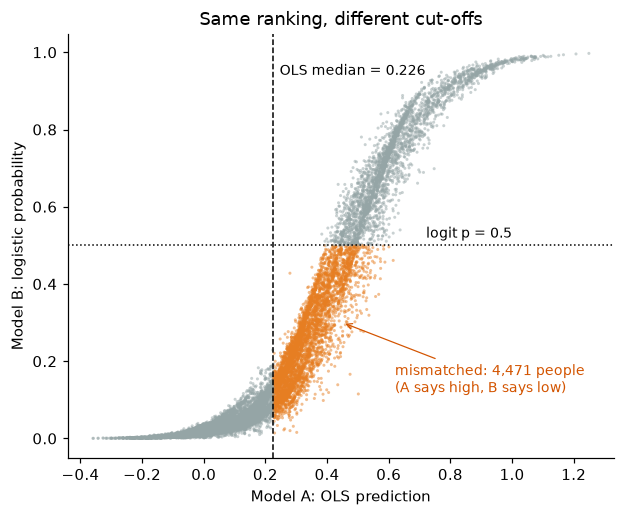

In [16]:
fig, ax = plt.subplots(figsize=(6.4, 5))
colors = np.where(mm, "#e67e22", "#95a5a6")
ax.scatter(pred_a, prob_b, s=4, c=colors, alpha=0.5, linewidths=0)
ax.axvline(median_a, color="black", ls="--", lw=1)
ax.axhline(0.5, color="black", ls=":", lw=1)
ax.text(median_a + 0.02, 0.97, f"OLS median = {median_a:.3f}", fontsize=9, va="top")
ax.text(1.0, 0.52, "logit p = 0.5", fontsize=9, ha="right")
ax.annotate(f"mismatched: {mismatch.sum():,} people\n(A says high, B says low)", xy=(0.45, 0.3),
            xytext=(0.62, 0.12), color="#d35400", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#d35400", lw=0.8))
ax.set_xlabel("Model A: OLS prediction")
ax.set_ylabel("Model B: logistic probability")
ax.set_title("Same ranking, different cut-offs")
fig.savefig(FIG_DIR / "fig1_ols_vs_logit.png")
plt.show()

## 3. Part 2.1: Simpson's paradox hunt

I split the training data by **marital status** (married vs unmarried) and track the coefficient on **sex** (`sex_Male`, baseline Female).

For each of the three groups (all training rows, married only, unmarried only) I fit two logistic regressions:

1. a *crude* one with sex as the only predictor (the raw trend), and
2. an *adjusted* one with the full Model B specification. Inside a subgroup, columns that never change are dropped automatically; for example, the marital status dummies are constant in the married group.

One fix was needed. In the unmarried group nobody in private household service, and nobody in the no-pay workclass, earns >50K. With zero positives in a category, the logit keeps pushing that coefficient towards minus infinity and never converges. `fit_logit` drops such columns for that subgroup only and prints which ones it dropped. Those people then sit in the baseline category. The cell after the results checks the other option, removing those rows instead, and the sex coefficient hardly changes.

In [17]:
train["married"] = (train["marital_status"] == "Married").astype(int)
test["married"] = (test["marital_status"] == "Married").astype(int)

rates = (train.groupby(["married", "sex"])["y"].agg(["mean", "size"])
         .rename(columns={"mean": "rate_over_50K", "size": "n"}))
print(rates.round(4), "\n")
print("overall >50K rate by sex:\n", train.groupby("sex")["y"].mean().round(4), "\n")
print("share of each sex that is married:\n", train.groupby("sex")["married"].mean().round(4))
rates.round(6).to_csv(TAB_DIR / "part2_1_rates_by_married_sex.csv")

                rate_over_50K      n
married sex                         
0       Female         0.0474   9494
        Male           0.0830   8924
1       Female         0.4473   1746
        Male           0.4431  13989 

overall >50K rate by sex:
 sex
Female    0.1095
Male      0.3029
Name: y, dtype: float64 

share of each sex that is married:
 sex
Female    0.1553
Male      0.6105
Name: married, dtype: float64


In [18]:
def fit_logit(data, num_cols=NUM_COLS, cat_cols=CAT_COLS, label=""):
    X = make_X(data, num_cols, cat_cols)
    # drop columns that do not vary inside this subset (e.g. marital dummies among married people)
    X = X.loc[:, (X.std() > 0) | (X.columns == "const")]
    # also drop dummies where everyone in that category has the same outcome. Their MLE is
    # minus (or plus) infinity, so the fit never converges (quasi-separation).
    dummies = [c for c in X.columns if c != "const" and set(X[c].unique()) <= {0.0, 1.0}]
    separated = [c for c in dummies if data.loc[X[c] == 1, "y"].nunique() < 2]
    if separated:
        print(f"{label}: dropped {separated} (no variation in income inside these categories)")
    return sm.Logit(data["y"], X.drop(columns=separated)).fit(disp=0, maxiter=200)


groups = {
    "Full training set": train,
    "Subgroup A: married": train[train["married"] == 1],
    "Subgroup B: unmarried": train[train["married"] == 0],
}

rows = []
simpson_models = {}
for name, d in groups.items():
    crude = sm.Logit(d["y"], sm.add_constant((d["sex"] == "Male").astype(float).rename("sex_Male"))).fit(disp=0)
    adj = fit_logit(d, label=name)
    simpson_models[name] = adj
    rows.append({
        "group": name, "n": len(d), "rate_over_50K": d["y"].mean(),
        "crude_coef": crude.params["sex_Male"],
        "crude_ci_low": crude.conf_int().loc["sex_Male", 0], "crude_ci_high": crude.conf_int().loc["sex_Male", 1],
        "crude_p": crude.pvalues["sex_Male"],
        "adj_coef": adj.params["sex_Male"],
        "adj_se": adj.bse["sex_Male"],
        "adj_ci_low": adj.conf_int().loc["sex_Male", 0], "adj_ci_high": adj.conf_int().loc["sex_Male", 1],
        "adj_p": adj.pvalues["sex_Male"], "adj_odds_ratio": np.exp(adj.params["sex_Male"]),
        "converged": adj.mle_retvals["converged"],
    })

simpson = pd.DataFrame(rows).set_index("group")
simpson.round(6).to_csv(TAB_DIR / "part2_1_sex_coefficient.csv")
simpson.round(4).T

Subgroup B: unmarried: dropped ['workclass_No-pay', 'occupation_Priv-house-serv'] (no variation in income inside these categories)


group,Full training set,Subgroup A: married,Subgroup B: unmarried
n,34153,15735,18418
rate_over_50K,0.2392,0.4436,0.0647
crude_coef,1.2621,-0.0169,0.5988
crude_ci_low,1.1965,-0.117,0.4779
crude_ci_high,1.3276,0.0832,0.7197
crude_p,0.0,0.7406,0.0
adj_coef,0.1599,-0.2884,0.7396
adj_se,0.0488,0.0651,0.0792
adj_ci_low,0.0642,-0.4159,0.5843
adj_ci_high,0.2556,-0.1609,0.8949


In [19]:
# is the married vs unmarried difference in the sex effect statistically real?
# (1) z-test on the two adjusted subgroup coefficients
a_ = simpson.loc["Subgroup A: married"]
b_ = simpson.loc["Subgroup B: unmarried"]
z = (a_["adj_coef"] - b_["adj_coef"]) / np.sqrt(a_["adj_se"] ** 2 + b_["adj_se"] ** 2)
p_z = 2 * stats.norm.sf(abs(z))
print(f"difference in sex_Male between subgroups: {a_['adj_coef'] - b_['adj_coef']:.3f}, z = {z:.2f}, p = {p_z:.2e}")

# (2) same idea with an interaction term in one model on the full training set
X_int = X_train.copy()
X_int["male_x_married"] = X_int["sex_Male"] * X_int["marital_status_Married"]
m_int = sm.Logit(y_train, X_int).fit(disp=0, maxiter=200)
print(m_int.params[["sex_Male", "marital_status_Married", "male_x_married"]].round(4))
print("interaction CI:", m_int.conf_int().loc["male_x_married"].round(4).tolist(),
      "p =", f"{m_int.pvalues['male_x_married']:.2e}")

# other predictors across the three adjusted models, for context
others = pd.DataFrame({g: m.params for g, m in simpson_models.items()}).loc[
    ["sex_Male", "age", "education_num", "hours_per_week", "capital_gain"]]
others.round(6).to_csv(TAB_DIR / "part2_1_other_coefficients.csv")
print(others.round(3))

key["simpson"] = {g: {k: (round(float(v), 4) if isinstance(v, (float, np.floating)) else v)
                      for k, v in r.items()} for g, r in simpson.drop(columns="converged").iterrows()}
key["simpson_rates"] = {f"{'married' if m else 'not_married'}_{s}": round(v, 4)
                        for (m, s), v in rates["rate_over_50K"].items()}
key["simpson_rate_female"] = round(train.loc[train.sex == "Female", "y"].mean(), 4)
key["simpson_rate_male"] = round(train.loc[train.sex == "Male", "y"].mean(), 4)
key["married_share_female"] = round(train.loc[train.sex == "Female", "married"].mean(), 4)
key["married_share_male"] = round(train.loc[train.sex == "Male", "married"].mean(), 4)
key["simpson_diff_z"] = round(z, 2)
key["simpson_diff_p"] = float(f"{p_z:.3g}")
key["interaction_coef"] = round(m_int.params["male_x_married"], 4)
key["interaction_ci"] = m_int.conf_int().loc["male_x_married"].round(4).tolist()
key["interaction_p"] = float(f"{m_int.pvalues['male_x_married']:.3g}")
key["interaction_main_sex"] = round(m_int.params["sex_Male"], 4)
key["interaction_implied_married"] = round(m_int.params["sex_Male"] + m_int.params["male_x_married"], 4)
key["crude_or_full"] = round(float(np.exp(simpson.loc["Full training set", "crude_coef"])), 2)
w_a, w_b = 1 / a_["adj_se"] ** 2, 1 / b_["adj_se"] ** 2
key["simpson_weighted_avg"] = round((w_a * a_["adj_coef"] + w_b * b_["adj_coef"]) / (w_a + w_b), 3)
print("precision-weighted average of the two subgroup coefficients:", key["simpson_weighted_avg"])
print("implied sex effect among the married from the interaction model:",
      round(m_int.params["sex_Male"] + m_int.params["male_x_married"], 3))
print("crude odds ratio for men in the full training set:", key["crude_or_full"])

difference in sex_Male between subgroups: -1.028, z = -10.03, p = 1.16e-23
sex_Male                  0.8008
marital_status_Married    3.4563
male_x_married           -1.1911
dtype: float64
interaction CI: [-1.3761, -1.006] p = 1.75e-36
                Full training set  Subgroup A: married  Subgroup B: unmarried
sex_Male                    0.160               -0.288                  0.740
age                         0.362                0.303                  0.637
education_num               0.757                0.714                  0.861
hours_per_week              0.368                0.320                  0.533
capital_gain                0.514                0.425                  0.679
precision-weighted average of the two subgroup coefficients: 0.126
implied sex effect among the married from the interaction model: -0.39
crude odds ratio for men in the full training set: 3.53


Two robustness checks. First, in the unmarried subgroup I dropped two dummy columns that had no high earners at all; here I instead drop the 160 people in those two categories. Second, above I used only the training rows (the data the model learned from). Here I refit the three adjusted models on all 48,790 rows.

In [20]:
unmarried = train[train["married"] == 0]
separated_rows = (unmarried["workclass"] == "No-pay") | (unmarried["occupation"] == "Priv-house-serv")
alt = fit_logit(unmarried[~separated_rows], label="unmarried, rows removed instead")
print(f"rows removed: {int(separated_rows.sum())}")
print(f"sex_Male, columns dropped: {simpson.loc['Subgroup B: unmarried', 'adj_coef']:.3f}"
      f"   rows dropped: {alt.params['sex_Male']:.3f} {alt.conf_int().loc['sex_Male'].round(3).tolist()}")

everyone = pd.concat([train, test])
robust = {}
for name, d in [("all rows", everyone), ("married", everyone[everyone.married == 1]),
                ("unmarried", everyone[everyone.married == 0])]:
    m_ = fit_logit(d, label=f"{name} (all 48,790 rows)")
    ci = m_.conf_int().loc["sex_Male"]
    robust[name] = {"n": len(d), "coef": round(m_.params["sex_Male"], 4),
                    "ci_low": round(ci[0], 4), "ci_high": round(ci[1], 4)}
robust = pd.DataFrame(robust).T
robust.to_csv(TAB_DIR / "part2_1_robustness_all_rows.csv")
print(robust)

key["simpson_alt_rows_removed"] = int(separated_rows.sum())
key["simpson_alt_coef"] = round(alt.params["sex_Male"], 4)
key["simpson_alt_ci"] = alt.conf_int().loc["sex_Male"].round(4).tolist()
key["simpson_all_rows"] = {k: {c: float(v) for c, v in r.items()} for k, r in robust.iterrows()}

rows removed: 160
sex_Male, columns dropped: 0.740   rows dropped: 0.729 [0.574, 0.884]


unmarried (all 48,790 rows): dropped ['workclass_No-pay'] (no variation in income inside these categories)
                 n    coef  ci_low  ci_high
all rows   48790.0  0.1511  0.0711   0.2311
married    22403.0 -0.2873 -0.3940  -0.1807
unmarried  26387.0  0.6889  0.5591   0.8186


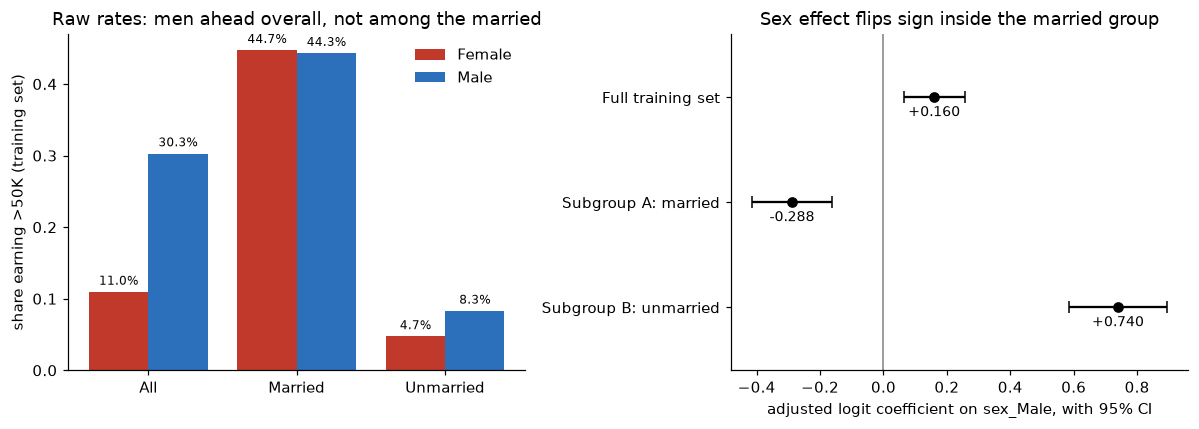

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

labels = ["All", "Married", "Unmarried"]
f_rates = [train.loc[train.sex == "Female", "y"].mean(),
           rates.loc[(1, "Female"), "rate_over_50K"], rates.loc[(0, "Female"), "rate_over_50K"]]
m_rates = [train.loc[train.sex == "Male", "y"].mean(),
           rates.loc[(1, "Male"), "rate_over_50K"], rates.loc[(0, "Male"), "rate_over_50K"]]
x = np.arange(3)
ax1.bar(x - 0.2, f_rates, 0.4, label="Female", color=FEMALE_C)
ax1.bar(x + 0.2, m_rates, 0.4, label="Male", color=MALE_C)
for i in range(3):
    ax1.text(x[i] - 0.2, f_rates[i] + 0.01, f"{f_rates[i]:.1%}", ha="center", fontsize=8)
    ax1.text(x[i] + 0.2, m_rates[i] + 0.01, f"{m_rates[i]:.1%}", ha="center", fontsize=8)
ax1.set_xticks(x, labels)
ax1.set_ylabel("share earning >50K (training set)")
ax1.set_title("Raw rates: men ahead overall, not among the married")
ax1.legend(frameon=False)

names = list(simpson.index)
for i, g in enumerate(names):
    r = simpson.loc[g]
    ax2.errorbar(r["adj_coef"], i, xerr=[[r["adj_coef"] - r["adj_ci_low"]], [r["adj_ci_high"] - r["adj_coef"]]],
                 fmt="o", color="black", capsize=4)
    ax2.text(r["adj_coef"], i + 0.18, f"{r['adj_coef']:+.3f}", ha="center", fontsize=9)
ax2.axvline(0, color="grey", lw=1)
ax2.set_yticks(range(3), names)
ax2.set_ylim(-0.6, 2.6)
ax2.invert_yaxis()
ax2.set_xlabel("adjusted logit coefficient on sex_Male, with 95% CI")
ax2.set_title("Sex effect flips sign inside the married group")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_simpson.png")
plt.show()

## 4. Part 2.2: Omitted-variable bias

The variable I drop is **marital status**. I expect leaving it out to distort the sex and age coefficients, since it is tied to both and strongly linked to income. In this sample men are far more likely to be recorded as married, married people earn much more, and married people are older. The full model is Model B. The reduced model is the same model with the three marital-status dummies removed.

In [22]:
reduced_cats = [c for c in CAT_COLS if c != "marital_status"]
model_red = sm.Logit(y_train, make_X(train, cat_cols=reduced_cats)).fit(disp=0, maxiter=200)
prob_red = model_red.predict(make_X(test, cat_cols=reduced_cats))

shared = [c for c in model_b.params.index if c in model_red.params.index and c != "const"]
ovb_all = pd.DataFrame({
    "full_coef": model_b.params[shared], "full_p": model_b.pvalues[shared],
    "reduced_coef": model_red.params[shared],
})
ovb_all["change"] = ovb_all["reduced_coef"] - ovb_all["full_coef"]
ovb_all["pct_change"] = ovb_all["change"] / ovb_all["full_coef"].abs() * 100
ovb_all["abs_change"] = ovb_all["change"].abs()
ovb_all = ovb_all.sort_values("abs_change", ascending=False)
ovb_all.round(6).to_csv(TAB_DIR / "part2_2_ovb_all.csv")

print(f"test AUC  full: {roc_auc_score(y_test, prob_b):.4f}   reduced: {roc_auc_score(y_test, prob_red):.4f}")
print(f"test accuracy at 0.5  full: {accuracy_score(y_test, prob_b >= 0.5):.4f}   "
      f"reduced: {accuracy_score(y_test, prob_red >= 0.5):.4f}\n")
ovb_all.round(3)

test AUC  full: 0.8981   reduced: 0.8515
test accuracy at 0.5  full: 0.8463   reduced: 0.8228



,full_coef,full_p,reduced_coef,change,pct_change,abs_change
sex_Male,0.160,0.001,1.132,0.972,607.859,0.972
workclass_No-pay,-0.761,0.347,-0.285,0.476,62.518,0.476
race_Black,-0.237,0.001,-0.459,-0.222,-93.702,0.222
age,0.362,0.000,0.583,0.221,61.165,0.221
occupation_Machine-op-inspct,-0.889,0.000,-0.696,0.193,21.680,0.193
occupation_Craft-repair,-0.542,0.000,-0.364,0.178,32.807,0.178
occupation_Transport-moving,-0.718,0.000,-0.553,0.165,23.032,0.165
race_Amer-Indian-Eskimo,-0.493,0.020,-0.632,-0.139,-28.177,0.139
workclass_Self-emp-inc,0.179,0.026,0.312,0.133,73.961,0.133
occupation_Priv-house-serv,-2.576,0.001,-2.706,-0.130,-5.059,0.130


In [23]:
# the eight predictors I report in the write-up
REPORT_PREDICTORS = ["sex_Male", "age", "race_Black", "workclass_Self-emp-inc",
                     "occupation_Exec-managerial", "hours_per_week", "education_num", "capital_gain"]
ovb = ovb_all.loc[REPORT_PREDICTORS, ["full_coef", "reduced_coef", "change", "pct_change"]]
ovb["full_odds_ratio"] = np.exp(ovb["full_coef"])
ovb["reduced_odds_ratio"] = np.exp(ovb["reduced_coef"])
ovb.round(6).to_csv(TAB_DIR / "part2_2_ovb_report.csv")
print(ovb.round(3), "\n")

# which coefficient moved the most? % change explodes for coefficients near zero,
# so I also rank by absolute change and restrict to coefficients that were significant to begin with
sig = ovb_all[ovb_all["full_p"] < 0.05]
print("largest absolute change:", ovb_all.index[0], round(ovb_all["abs_change"].iloc[0], 3))
print("largest % change (all):", ovb_all["pct_change"].abs().idxmax(), round(ovb_all["pct_change"].abs().max(), 1))
print("largest % change (significant in full model):", sig["pct_change"].abs().idxmax(),
      round(sig["pct_change"].abs().max(), 1))

                            full_coef  reduced_coef  change  pct_change  full_odds_ratio  reduced_odds_ratio
sex_Male                        0.160         1.132   0.972     607.859            1.173               3.102
age                             0.362         0.583   0.221      61.165            1.436               1.791
race_Black                     -0.237        -0.459  -0.222     -93.702            0.789               0.632
workclass_Self-emp-inc          0.179         0.312   0.133      73.961            1.196               1.366
occupation_Exec-managerial      0.212         0.270   0.059      27.664            1.236               1.310
hours_per_week                  0.368         0.390   0.021       5.765            1.445               1.476
education_num                   0.757         0.682  -0.075      -9.952            2.132               1.977
capital_gain                    0.514         0.498  -0.016      -3.054            1.672               1.646 

largest absolute 

In [24]:
# why each one moved: how married-ness lines up with the other predictors
t_ = train.assign(
    is_black=(train.race == "Black").astype(int),
    is_selfinc=(train.workclass == "Self-emp-inc").astype(int),
    is_exec=(train.occupation == "Exec-managerial").astype(int),
)
married_share = pd.Series({
    "men": t_.loc[t_.sex == "Male", "married"].mean(),
    "women": t_.loc[t_.sex == "Female", "married"].mean(),
    "Black": t_.loc[t_.is_black == 1, "married"].mean(),
    "non-Black": t_.loc[t_.is_black == 0, "married"].mean(),
    "self-employed (inc)": t_.loc[t_.is_selfinc == 1, "married"].mean(),
    "everyone else": t_.loc[t_.is_selfinc == 0, "married"].mean(),
    "exec-managerial": t_.loc[t_.is_exec == 1, "married"].mean(),
}).round(4)
print("share married:\n", married_share, "\n")
corr = t_[["married", "age", "hours_per_week", "education_num", "capital_gain"]].corr()["married"].round(4)
print("correlation of 'married' with numeric predictors:\n", corr)
print("mean age, married vs not:", t_.groupby("married")["age"].mean().round(1).to_dict())

key["ovb"] = {k: {c: round(float(v), 4) for c, v in r.items()} for k, r in ovb.iterrows()}
key["ovb_auc_full"] = round(roc_auc_score(y_test, prob_b), 4)
key["ovb_auc_reduced"] = round(roc_auc_score(y_test, prob_red), 4)
key["ovb_acc_full"] = round(accuracy_score(y_test, prob_b >= 0.5), 4)
key["ovb_acc_reduced"] = round(accuracy_score(y_test, prob_red >= 0.5), 4)
key["ovb_married_share"] = married_share.to_dict()
key["ovb_corr_married"] = corr.drop("married").to_dict()
key["ovb_mean_age_married"] = t_.groupby("married")["age"].mean().round(1).to_dict()
key["marital_married_coef"] = round(model_b.params["marital_status_Married"], 4)
key["marital_married_or"] = round(np.exp(model_b.params["marital_status_Married"]), 2)

share married:
 men                    0.6105
women                  0.1553
Black                  0.2688
non-Black              0.4813
self-employed (inc)    0.7403
everyone else          0.4507
exec-managerial        0.5933
dtype: float64 

correlation of 'married' with numeric predictors:
 married           1.0000
age               0.3169
hours_per_week    0.2173
education_num     0.0851
capital_gain      0.1274
Name: married, dtype: float64
mean age, married vs not: {0: 34.6, 1: 43.3}


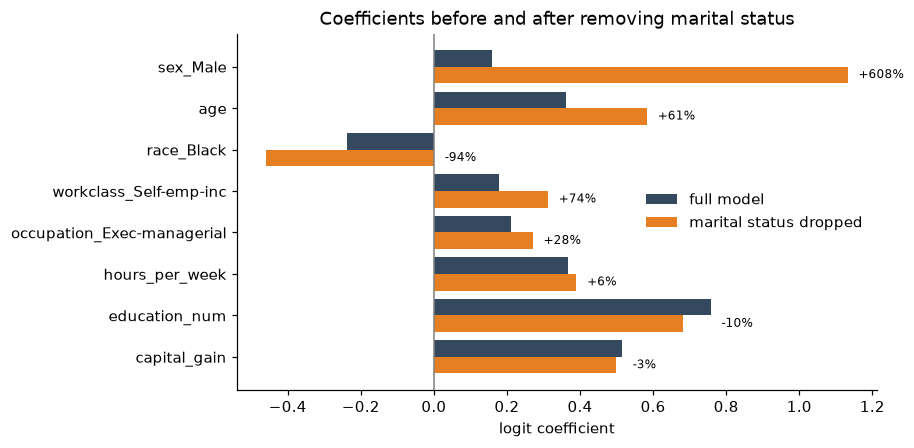

In [25]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
y_pos = np.arange(len(ovb))
ax.barh(y_pos - 0.2, ovb["full_coef"], 0.4, label="full model", color="#34495e")
ax.barh(y_pos + 0.2, ovb["reduced_coef"], 0.4, label="marital status dropped", color="#e67e22")
for i, (f, r, pct) in enumerate(zip(ovb["full_coef"], ovb["reduced_coef"], ovb["pct_change"])):
    ax.text(max(f, r, 0) + 0.03, i + 0.2, f"{pct:+.0f}%", va="center", fontsize=8)
ax.set_yticks(y_pos, ovb.index)
ax.invert_yaxis()
ax.axvline(0, color="grey", lw=1)
ax.set_xlabel("logit coefficient")
ax.set_title("Coefficients before and after removing marital status")
ax.legend(frameon=False, loc="center right")
fig.savefig(FIG_DIR / "fig3_ovb.png")
plt.show()

## 5. Part 2.3: Adversarial subset

On the test set I look for confident mistakes: P(>50K) ≥ 0.75 when the person actually earns ≤50K (confident false positive), or P ≤ 0.25 when they actually earn >50K (confident false negative). From those I draw 50 rows at random with seed 138.

In [26]:
test["p"] = prob_b
conf_fp = (test["p"] >= 0.75) & (test["y"] == 0)
conf_fn = (test["p"] <= 0.25) & (test["y"] == 1)
confident = (test["p"] >= 0.75) | (test["p"] <= 0.25)
adv_all = test[conf_fp | conf_fn].copy()
adv_all["error_type"] = np.where(adv_all["p"] >= 0.75, "confident FP", "confident FN")

print(f"confident false positives: {conf_fp.sum()}")
print(f"confident false negatives: {conf_fn.sum()}")
print(f"total: {len(adv_all)} = {len(adv_all) / len(test):.2%} of the test set "
      f"({len(adv_all) / confident.sum():.2%} of the {confident.sum()} confident predictions)")

adv50 = adv_all.sample(50, random_state=SEED)
print("\nin the 50-row sample:", adv50["error_type"].value_counts().to_dict())
adv50[["error_type", "p", "y", "age", "sex", "race", "marital_status", "education", "occupation",
       "hours_per_week", "relationship"]].sort_values("error_type").to_csv(TAB_DIR / "part2_3_adversarial_50_rows.csv")

key.update({
    "adv_fp": int(conf_fp.sum()), "adv_fn": int(conf_fn.sum()), "adv_total": len(adv_all),
    "adv_pct_test": round(len(adv_all) / len(test) * 100, 2),
    "adv_n_confident": int(confident.sum()),
    "adv_pct_of_confident": round(len(adv_all) / confident.sum() * 100, 2),
    "adv50_fp": int((adv50.error_type == "confident FP").sum()),
    "adv50_fn": int((adv50.error_type == "confident FN").sum()),
})

confident false positives: 215
confident false negatives: 623
total: 838 = 5.73% of the test set (7.70% of the 10877 confident predictions)

in the 50-row sample: {'confident FN': 37, 'confident FP': 13}


In [27]:
def profile(d):
    return pd.Series({
        "n": len(d),
        "mean age": d["age"].mean(), "median age": d["age"].median(),
        "age under 30 (%)": (d["age"] < 30).mean() * 100,
        "age 30-49 (%)": d["age"].between(30, 49).mean() * 100,
        "age 50+ (%)": (d["age"] >= 50).mean() * 100,
        "male (%)": (d["sex"] == "Male").mean() * 100,
        "married (%)": (d["marital_status"] == "Married").mean() * 100,
        "White (%)": (d["race"] == "White").mean() * 100,
        "Black (%)": (d["race"] == "Black").mean() * 100,
        "born outside US (%)": (d["native_country"] == "Non-US").mean() * 100,
        "bachelor's or higher (%)": (d["education_num"] >= 13).mean() * 100,
        "mean education_num": d["education_num"].mean(),
        "works 40+ hours (%)": (d["hours_per_week"] >= 40).mean() * 100,
        "any capital gain (%)": (d["capital_gain"] > 0).mean() * 100,
        "actually earns >50K (%)": d["y"].mean() * 100,
    })


demo = pd.DataFrame({"50-row sample": profile(adv50), "all 838 confident errors": profile(adv_all),
                     "full test set": profile(test)})
demo.columns = ["50-row sample", f"all {len(adv_all)} confident errors", "full test set"]
demo.round(1).to_csv(TAB_DIR / "part2_3_demographics.csv")
demo.round(1)

,50-row sample,all 838 confident errors,full test set
n,50.0,838.0,14637.0
mean age,41.5,43.4,38.8
median age,38.5,41.0,37.0
age under 30 (%),8.0,11.5,29.5
age 30-49 (%),64.0,58.6,48.1
age 50+ (%),28.0,30.0,22.4
male (%),78.0,75.2,66.3
married (%),68.0,63.7,45.6
White (%),90.0,87.5,86.0
Black (%),4.0,6.9,9.4


In [28]:
# searching for the trait the 50 rows share: share in sample vs share in test set
traits = {
    "aged 30+": lambda d: d.age >= 30,
    "works 40+ hours": lambda d: d.hours_per_week >= 40,
    "aged 30+ AND works 40+ hours": lambda d: (d.age >= 30) & (d.hours_per_week >= 40),
    "married": lambda d: d.marital_status == "Married",
    "male": lambda d: d.sex == "Male",
    "bachelor's or higher": lambda d: d.education_num >= 13,
    "no capital gain": lambda d: d.capital_gain == 0,
    "private sector": lambda d: d.workclass == "Private",
}
trait_tab = pd.DataFrame({
    "sample_pct": {k: f(adv50).mean() * 100 for k, f in traits.items()},
    "test_pct": {k: f(test).mean() * 100 for k, f in traits.items()},
})
trait_tab["lift"] = trait_tab["sample_pct"] / trait_tab["test_pct"]
trait_tab = trait_tab.sort_values("lift", ascending=False)
trait_tab.round(2).to_csv(TAB_DIR / "part2_3_traits.csv")
print(trait_tab.round(2), "\n")

# split by error type, since FPs and FNs fail for different reasons
for kind, d in adv50.groupby("error_type"):
    print(kind, len(d), "rows")
    print("  married:", (d.marital_status == "Married").mean().round(3),
          "| bachelor's+:", (d.education_num >= 13).mean().round(3),
          "| aged 30+ & 40+ hrs:", ((d.age >= 30) & (d.hours_per_week >= 40)).mean().round(3))
fn50 = adv50[adv50.error_type == "confident FN"]
fn_married = fn50[fn50.marital_status == "Married"]
fn_unmarried = fn50[fn50.marital_status != "Married"]
print("FN married without a degree:", int((fn_married.education_num < 13).sum()), "of", len(fn_married))
print("FN unmarried with a degree:", int((fn_unmarried.education_num >= 13).sum()), "of", len(fn_unmarried))
print("machine operators in sample:", int((adv50.occupation == "Machine-op-inspct").sum()),
      f"({(adv50.occupation == 'Machine-op-inspct').mean():.0%}) vs test {(test.occupation == 'Machine-op-inspct').mean():.1%}")

tr = trait_tab.loc["aged 30+ AND works 40+ hours"]
key.update({
    "adv_trait_sample_pct": round(tr["sample_pct"], 1), "adv_trait_test_pct": round(tr["test_pct"], 1),
    "adv_married_sample_pct": round(trait_tab.loc["married", "sample_pct"], 1),
    "adv_married_test_pct": round(trait_tab.loc["married", "test_pct"], 1),
    "adv_age30_sample_pct": round(trait_tab.loc["aged 30+", "sample_pct"], 1),
    "adv_age30_test_pct": round(trait_tab.loc["aged 30+", "test_pct"], 1),
    "adv_hours40_sample_pct": round(trait_tab.loc["works 40+ hours", "sample_pct"], 1),
    "adv_hours40_test_pct": round(trait_tab.loc["works 40+ hours", "test_pct"], 1),
    "adv_male_sample_pct": round(trait_tab.loc["male", "sample_pct"], 1),
    "adv_male_test_pct": round(trait_tab.loc["male", "test_pct"], 1),
    "adv_fp_married_pct": round((adv50[adv50.error_type == "confident FP"].marital_status == "Married").mean() * 100, 1),
    "adv_fp_degree_n": int((adv50[adv50.error_type == "confident FP"].education_num >= 13).sum()),
    "adv_fn_married_n": len(fn_married), "adv_fn_married_nodegree_n": int((fn_married.education_num < 13).sum()),
    "adv_fn_unmarried_n": len(fn_unmarried), "adv_fn_unmarried_degree_n": int((fn_unmarried.education_num >= 13).sum()),
    "adv_machineop_n": int((adv50.occupation == "Machine-op-inspct").sum()),
    "adv_machineop_test_pct": round((test.occupation == "Machine-op-inspct").mean() * 100, 1),
})

                              sample_pct  test_pct  lift
bachelor's or higher                46.0     25.18  1.83
married                             68.0     45.56  1.49
aged 30+ AND works 40+ hours        82.0     57.34  1.43
aged 30+                            92.0     70.48  1.31
works 40+ hours                     90.0     75.71  1.19
male                                78.0     66.28  1.18
private sector                      74.0     74.89  0.99
no capital gain                     90.0     91.58  0.98

 

confident FN 37 rows
  married: 0.568 | bachelor's+: 0.297 | aged 30+ & 40+ hrs: 0.838
confident FP 13 rows
  married: 1.0 | bachelor's+: 0.923 | aged 30+ & 40+ hrs: 0.769
FN married without a degree: 21 of 21
FN unmarried with a degree: 11 of 16
machine operators in sample: 11 (22%) vs test 6.1%


In [29]:
# the age/hours trait could just reflect that 74% of the sample really earn >50K,
# so compare against people with the same true label
prime = (test.age >= 30) & (test.hours_per_week >= 40)
print(f"aged 30+ & 40+ hrs among all >50K earners in test: {prime[test.y == 1].mean():.1%}  "
      f"| among the 37 FNs: {((fn50.age >= 30) & (fn50.hours_per_week >= 40)).mean():.1%}")
print(f"aged 30+ & 40+ hrs among all <=50K earners in test: {prime[test.y == 0].mean():.1%}")

# the trait that does separate them: does their marriage + degree profile point the wrong way?
married_grad = (test.marital_status == "Married") & (test.education_num >= 13)
fp50 = adv50[adv50.error_type == "confident FP"]
fp_mg = int(married_grad[fp50.index].sum())
fn_not_mg = int((~married_grad[fn50.index]).sum())
print(f"\nFPs who are married graduates: {fp_mg} of {len(fp50)}"
      f"  (vs {married_grad[test.y == 0].mean():.1%} of all <=50K earners in test)")
print(f"FNs who are NOT married graduates: {fn_not_mg} of {len(fn50)}"
      f"  (vs {(~married_grad)[test.y == 1].mean():.1%} of all >50K earners in test)")
print(f"profile points the wrong way: {fp_mg + fn_not_mg} of 50")
mo_married_fn = int(((fn50.marital_status == "Married") & (fn50.occupation == "Machine-op-inspct")).sum())
print("machine operators among the married FNs:", mo_married_fn)

key.update({
    "prime_share_rich_test": round(prime[test.y == 1].mean() * 100, 1),
    "prime_share_poor_test": round(prime[test.y == 0].mean() * 100, 1),
    "prime_share_fn50": round(((fn50.age >= 30) & (fn50.hours_per_week >= 40)).mean() * 100, 1),
    "adv_fp_married_grad": fp_mg, "adv_fn_not_married_grad": fn_not_mg,
    "adv_profile_wrong": fp_mg + fn_not_mg,
    "married_grad_share_poor_test": round(married_grad[test.y == 0].mean() * 100, 1),
    "not_married_grad_share_rich_test": round((~married_grad)[test.y == 1].mean() * 100, 1),
    "adv_machineop_married_fn": mo_married_fn,
    "adv_unmarried_fn_never": int((fn50.marital_status == "Never-married").sum()),
    "adv_unmarried_fn_divsep": int((fn50.marital_status == "Div-Sep").sum()),
})

aged 30+ & 40+ hrs among all >50K earners in test: 84.3%  | among the 37 FNs: 83.8%
aged 30+ & 40+ hrs among all <=50K earners in test: 48.8%

FPs who are married graduates: 12 of 13  (vs 5.3% of all <=50K earners in test)
FNs who are NOT married graduates: 37 of 37  (vs 59.4% of all >50K earners in test)
profile points the wrong way: 49 of 50
machine operators among the married FNs: 10


In [30]:
# how big is the married effect next to a realistic education step?
edu_step_sd = (13 - 9) / scaler.scale_[NUM_COLS.index("education_num")]
print(f"high school (9) -> bachelor's (13) = {edu_step_sd:.2f} SD -> +{edu_step_sd * model_b.params['education_num']:.2f} log-odds")
print(f"married vs never-married: +{model_b.params['marital_status_Married']:.3f}; "
      f"married vs divorced/separated: +{model_b.params['marital_status_Married'] - model_b.params['marital_status_Div-Sep']:.3f}")

# would fixing the two misspecifications (no interaction, straight-line age) remove the confident errors?
def add_terms(X):
    X = X.copy()
    X["male_x_married"] = X["sex_Male"] * X["marital_status_Married"]
    X["age_sq"] = X["age"] ** 2
    return X

m_fix = sm.Logit(y_train, add_terms(X_train)).fit(disp=0, maxiter=200)
p_fix = m_fix.predict(add_terms(X_test))
n_conf_fix = int((((p_fix >= 0.75) & (y_test == 0)) | ((p_fix <= 0.25) & (y_test == 1))).sum())
print(f"confident errors with interaction + age^2: {n_conf_fix} (was {len(adv_all)})")
print("sampled rows aged over 65:", int((adv50.age > 65).sum()))

grads = test[test.education_num >= 13]
mg, ug = grads[grads.married == 1], grads[grads.married == 0]
mg_poor = mg[mg.y == 0]
print(f"married graduates in test: {len(mg)}, median p {mg.p.median():.3f}, share with p >= 0.75: {(mg.p >= 0.75).mean():.1%}")
print(f"married graduates earning <=50K: {len(mg_poor)}, of whom p >= 0.75: {int((mg_poor.p >= 0.75).sum())}")
print(f"unmarried graduates in test: {len(ug)}, share with p <= 0.25: {(ug.p <= 0.25).mean():.1%}")
print("sampled FPs in Exec-managerial or Prof-specialty:", int(fp50.occupation.isin(["Exec-managerial", "Prof-specialty"]).sum()),
      "| working 50+ hours:", int((fp50.hours_per_week >= 50).sum()))
key.update({
    "mg_n": len(mg), "mg_median_p": round(mg.p.median(), 3), "mg_pct_above75": round((mg.p >= 0.75).mean() * 100, 1),
    "mg_poor_n": len(mg_poor), "mg_poor_above75": int((mg_poor.p >= 0.75).sum()),
    "ug_pct_below25": round((ug.p <= 0.25).mean() * 100, 1),
    "fp50_exec_prof": int(fp50.occupation.isin(["Exec-managerial", "Prof-specialty"]).sum()),
    "fp50_50h": int((fp50.hours_per_week >= 50).sum()),
})
key.update({
    "edu_step_sd": round(edu_step_sd, 2), "edu_step_logodds": round(edu_step_sd * model_b.params["education_num"], 2),
    "married_vs_divsep": round(model_b.params["marital_status_Married"] - model_b.params["marital_status_Div-Sep"], 3),
    "married_vs_widowed": round(model_b.params["marital_status_Married"] - model_b.params["marital_status_Widowed"], 3),
    "adv_after_fix": n_conf_fix, "adv50_over65": int((adv50.age > 65).sum()),
})

high school (9) -> bachelor's (13) = 1.56 SD -> +1.18 log-odds
married vs never-married: +2.586; married vs divorced/separated: +2.136
confident errors with interaction + age^2: 819 (was 838)
sampled rows aged over 65: 2
married graduates in test: 2011, median p 0.745, share with p >= 0.75: 48.9%
married graduates earning <=50K: 585, of whom p >= 0.75: 157
unmarried graduates in test: 1675, share with p <= 0.25: 79.2%
sampled FPs in Exec-managerial or Prof-specialty: 12 | working 50+ hours: 7


In [31]:
# which part of the model pushed each of the 50 people the wrong way?
# contribution = coefficient * value, compared with the average person in the test set.
# dummies are grouped back into their original variable.
contrib = X_test.loc[adv50.index].drop(columns="const") * model_b.params.drop("const")
avg = (X_test.drop(columns="const") * model_b.params.drop("const")).mean()
dev = contrib - avg


def var_name(col):
    for c in CAT_COLS:
        if col.startswith(c + "_"):
            return c
    return col


dev_by_var = dev.T.groupby(var_name).sum().T
wrong_push = [dev_by_var.loc[i].idxmax() if t == "confident FP" else dev_by_var.loc[i].idxmin()
              for i, t in zip(adv50.index, adv50.error_type)]
push_counts = pd.Series(wrong_push).value_counts()
push_counts.to_csv(TAB_DIR / "part2_3_biggest_wrong_push.csv")
print("variable giving the biggest push in the wrong direction:\n", push_counts)
key["adv_push_counts"] = push_counts.to_dict()

variable giving the biggest push in the wrong direction:
 marital_status    23
occupation        13
education_num      7
capital_gain       3
workclass          2
job_missing        1
race               1
Name: count, dtype: int64


In [32]:
# is the model actually overconfident, or just honest about uncertain people?
bins = [0, 0.05, 0.15, 0.25, 0.5, 0.75, 0.9, 1.0]
test["p_bin"] = pd.cut(test["p"], bins, include_lowest=True)
calib = test.groupby("p_bin", observed=True).agg(n=("y", "size"), mean_p=("p", "mean"), actual_rate=("y", "mean"))
calib.round(3).to_csv(TAB_DIR / "part2_3_calibration.csv")
print(calib.round(3), "\n")

# linear age term vs the real age pattern
test["age_band"] = pd.cut(test["age"], [16, 25, 35, 45, 55, 65, 90])
age_check = test.groupby("age_band", observed=True).agg(n=("y", "size"), actual_rate=("y", "mean"), mean_p=("p", "mean"))
age_check.round(3).to_csv(TAB_DIR / "part2_3_age_bands.csv")
print(age_check.round(3))

low = test["p"] <= 0.25
high = test["p"] >= 0.75
# if the model were perfectly calibrated, how many confident mistakes would we expect?
exp_fn = test.loc[low, "p"].sum()
exp_fp = (1 - test.loc[high, "p"]).sum()
print(f"\nexpected confident FNs if calibrated: {exp_fn:.0f} (observed {conf_fn.sum()})")
print(f"expected confident FPs if calibrated: {exp_fp:.0f} (observed {conf_fp.sum()})")
key.update({"expected_fn": round(exp_fn, 1), "expected_fp": round(exp_fp, 1)})
key.update({
    "calib_low_n": int(low.sum()), "calib_low_mean_p": round(test.loc[low, "p"].mean(), 4),
    "calib_low_actual": round(test.loc[low, "y"].mean(), 4),
    "calib_high_n": int(high.sum()), "calib_high_mean_p": round(test.loc[high, "p"].mean(), 4),
    "calib_high_actual": round(test.loc[high, "y"].mean(), 4),
    "age_65plus_actual": round(age_check["actual_rate"].iloc[-1], 3), "age_65plus_pred": round(age_check["mean_p"].iloc[-1], 3),
    "age_45_55_actual": round(age_check["actual_rate"].iloc[3], 3), "age_45_55_pred": round(age_check["mean_p"].iloc[3], 3),
})

                   n  mean_p  actual_rate
p_bin                                    
(-0.001, 0.05]  5606   0.018        0.011
(0.05, 0.15]    2550   0.092        0.089
(0.15, 0.25]    1449   0.198        0.231
(0.25, 0.5]     2184   0.360        0.381
(0.5, 0.75]     1576   0.626        0.633
(0.75, 0.9]      794   0.819        0.780
(0.9, 1.0]       478   0.946        0.916 

             n  actual_rate  mean_p
age_band                           
(16, 25]  2886        0.017   0.040
(25, 35]  3764        0.186   0.194
(35, 45]  3572        0.340   0.311
(45, 55]  2513        0.399   0.365
(55, 65]  1336        0.314   0.343
(65, 90]   566        0.216   0.297

expected confident FNs if calibrated: 623 (observed 623)
expected confident FPs if calibrated: 169 (observed 215)


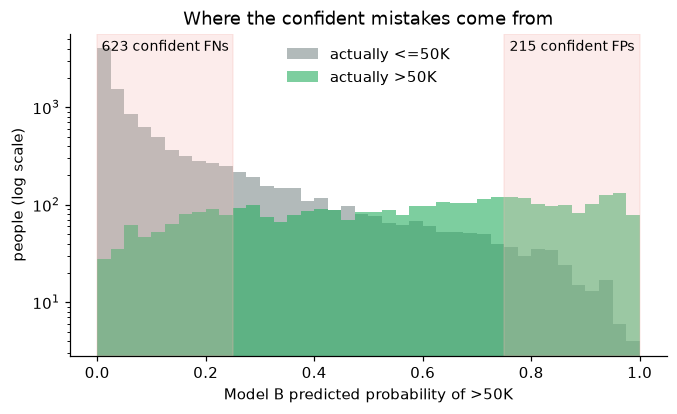

In [33]:
fig, ax = plt.subplots(figsize=(7, 3.8))
bins_h = np.linspace(0, 1, 41)
ax.hist(test.loc[test.y == 0, "p"], bins=bins_h, alpha=0.6, label="actually <=50K", color="#7f8c8d")
ax.hist(test.loc[test.y == 1, "p"], bins=bins_h, alpha=0.6, label="actually >50K", color="#27ae60")
ax.axvspan(0, 0.25, color="#f5b7b1", alpha=0.25)
ax.axvspan(0.75, 1, color="#f5b7b1", alpha=0.25)
ax.text(0.125, ax.get_ylim()[1] * 0.9, f"{conf_fn.sum()} confident FNs", ha="center", fontsize=9)
ax.text(0.875, ax.get_ylim()[1] * 0.9, f"{conf_fp.sum()} confident FPs", ha="center", fontsize=9)
ax.set_yscale("log")
ax.set_xlabel("Model B predicted probability of >50K")
ax.set_ylabel("people (log scale)")
ax.set_title("Where the confident mistakes come from")
ax.legend(frameon=False, loc="upper center")
fig.savefig(FIG_DIR / "fig4_adversarial.png")
plt.show()

## 6. Part 2.4: Fairness trade-off analysis

Sensitive variable: **sex**. Group A = Female, Group B = Male. I picked women as Group A on purpose. They are the group with the lower base rate, so the DP ratio and both EO ratios (TPR and FPR) come out below 1 at every threshold. Because equalized odds is defined as the *minimum* of two ratios, putting the disadvantaged group on top makes the min pick up the bigger gap. With the groups the other way round, the min would choose a ratio near 1 and hide the problem.

To make the fairness language concrete I assume the model is used for something like pre-approving people for a credit product that needs an income above $50K. Being predicted ">50K" (Ŷ=1) is then the **favourable** outcome.

* DP = P(Ŷ=1 | F) / P(Ŷ=1 | M)
* EO = min(TPR_F / TPR_M, FPR_F / FPR_M)
* PP = P(Y=1 | Ŷ=1, F) / P(Y=1 | Ŷ=1, M)

In [34]:
def group_rates(d, t):
    pred = d["p"] >= t
    pos, neg = d["y"] == 1, d["y"] == 0
    return {
        "sel": pred.mean(), "tpr": pred[pos].mean(), "fpr": pred[neg].mean(),
        "ppv": d.loc[pred, "y"].mean() if pred.sum() > 0 else np.nan,
        "acc": (pred == d["y"].astype(bool)).mean(),
        "n_flagged": int(pred.sum()), "n_fp": int((pred & neg).sum()), "n_tp": int((pred & pos).sum()),
    }


def fairness_sweep(d, col, group_a, group_b, thresholds):
    out = []
    for t in thresholds:
        A = group_rates(d[d[col] == group_a], t)
        B = group_rates(d[d[col] == group_b], t)
        out.append({
            "threshold": t,
            "DP": A["sel"] / B["sel"],
            "EO": min(A["tpr"] / B["tpr"], A["fpr"] / B["fpr"]),
            "PP": A["ppv"] / B["ppv"],
            "TPR_ratio": A["tpr"] / B["tpr"], "FPR_ratio": A["fpr"] / B["fpr"],
            "accuracy": ((d["p"] >= t) == d["y"].astype(bool)).mean(),
            "flagged_pct": (d["p"] >= t).mean() * 100,
            **{f"{k}_A": v for k, v in A.items()}, **{f"{k}_B": v for k, v in B.items()},
        })
    return pd.DataFrame(out).set_index("threshold")


THRESHOLDS = np.round(np.arange(0.05, 0.96, 0.10), 2)
fair = fairness_sweep(test, "sex", "Female", "Male", THRESHOLDS)
fair.round(6).to_csv(TAB_DIR / "part2_4_fairness_full.csv")
fair[["DP", "EO", "PP", "accuracy", "TPR_ratio", "FPR_ratio"]].round(3)

,DP,EO,PP,accuracy,TPR_ratio,FPR_ratio
threshold,,,,,,
0.05,0.600,0.612,0.578,0.614,0.975,0.612
0.15,0.358,0.320,0.857,0.758,0.863,0.320
0.25,0.285,0.244,0.929,0.811,0.745,0.244
0.35,0.260,0.210,0.978,0.837,0.716,0.210
0.45,0.238,0.189,0.991,0.845,0.664,0.189
0.55,0.214,0.155,1.024,0.844,0.617,0.155
0.65,0.187,0.121,1.047,0.835,0.550,0.121
0.75,0.153,0.098,1.036,0.818,0.446,0.098
0.85,0.161,0.060,1.069,0.797,0.484,0.060


In [35]:
# group-level detail behind the ratios (A = Female, B = Male)
fair[["sel_A", "sel_B", "tpr_A", "tpr_B", "fpr_A", "fpr_B", "ppv_A", "ppv_B",
      "acc_A", "acc_B", "n_flagged_A", "n_fp_A", "n_flagged_B", "n_fp_B"]].round(3)

,sel_A,sel_B,tpr_A,tpr_B,fpr_A,fpr_B,ppv_A,ppv_B,acc_A,acc_B,n_flagged_A,n_fp_A,n_flagged_B,n_fp_B
threshold,,,,,,,,,,,,,,
0.05,0.428,0.713,0.961,0.986,0.363,0.593,0.245,0.424,0.672,0.585,2113,1596,6918,3988
0.15,0.202,0.565,0.809,0.937,0.128,0.401,0.435,0.508,0.865,0.703,999,564,5482,2696
0.25,0.129,0.453,0.638,0.856,0.067,0.275,0.538,0.579,0.901,0.765,638,295,4394,1850
0.35,0.094,0.363,0.545,0.761,0.039,0.187,0.629,0.643,0.915,0.797,466,173,3520,1258
0.45,0.070,0.292,0.441,0.664,0.024,0.128,0.689,0.695,0.917,0.808,344,107,2836,864
0.55,0.050,0.236,0.351,0.570,0.014,0.088,0.759,0.741,0.917,0.807,249,60,2285,592
0.65,0.034,0.180,0.253,0.460,0.007,0.056,0.819,0.783,0.912,0.795,166,30,1745,379
0.75,0.019,0.122,0.147,0.329,0.003,0.030,0.859,0.829,0.904,0.774,92,13,1180,202
0.85,0.011,0.067,0.093,0.192,0.001,0.011,0.943,0.883,0.901,0.745,53,3,647,76


In [36]:
# the default 0.5 threshold is not in the sweep, so compute it separately for reference
at_half = fairness_sweep(test, "sex", "Female", "Male", [0.5]).iloc[0]
print(at_half[["DP", "EO", "PP", "TPR_ratio", "FPR_ratio", "accuracy", "tpr_A", "tpr_B", "acc_A", "acc_B"]].round(4))
print("\nbase rates in test set:", test.groupby("sex")["y"].mean().round(4).to_dict())
key["fair_at_half"] = {k: round(float(at_half[k]), 4) for k in
                       ["DP", "EO", "PP", "TPR_ratio", "FPR_ratio", "accuracy", "tpr_A", "tpr_B",
                        "fpr_A", "fpr_B", "acc_A", "acc_B", "sel_A", "sel_B"]}
key["test_base_rate_female"] = round(test.loc[test.sex == "Female", "y"].mean(), 4)
key["test_base_rate_male"] = round(test.loc[test.sex == "Male", "y"].mean(), 4)
key["test_n_female"] = int((test.sex == "Female").sum())
key["test_n_male"] = int((test.sex == "Male").sum())
key["fair"] = {f"{t:.2f}": {k: (round(float(v), 4) if pd.notna(v) else None) for k, v in r.items()}
               for t, r in fair.iterrows()}

DP           0.2288
EO           0.1738
PP           1.0094
TPR_ratio    0.6492
FPR_ratio    0.1738
accuracy     0.8463
tpr_A        0.4015
tpr_B        0.6184
acc_A        0.9184
acc_B        0.8096
Name: 0.5, dtype: float64

base rates in test set: {'Female': 0.109, 'Male': 0.3064}


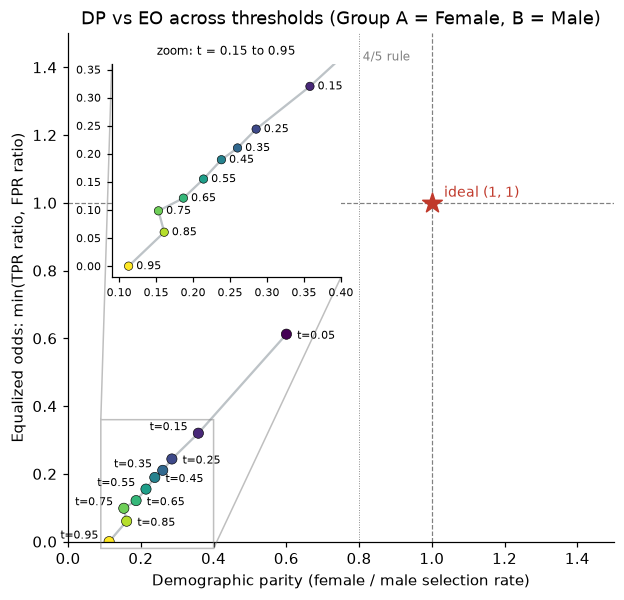

In [37]:
fig, ax = plt.subplots(figsize=(6.4, 6))
ax.plot(fair["DP"], fair["EO"], "-", color="#bdc3c7", zorder=1)
ax.scatter(fair["DP"], fair["EO"], c=fair.index, cmap="viridis", s=45, zorder=2, edgecolor="black", linewidth=0.4)
# points bunch up between t=0.25 and t=0.95, so alternate the labels left and right
for k, (t, r) in enumerate(fair.iterrows()):
    offset, ha = ((7, -3), "left") if k % 2 == 0 else ((-7, 2), "right")
    ax.annotate(f"t={t:.2f}", (r["DP"], r["EO"]), textcoords="offset points", xytext=offset, ha=ha, fontsize=7.5)

# zoomed view of the crowded corner
inset = ax.inset_axes([0.08, 0.52, 0.42, 0.42])
inset.plot(fair["DP"], fair["EO"], "-", color="#bdc3c7", zorder=1)
inset.scatter(fair["DP"], fair["EO"], c=fair.index, cmap="viridis", s=30, zorder=2, edgecolor="black", linewidth=0.4)
for t, r in fair.iterrows():
    inset.annotate(f"{t:.2f}", (r["DP"], r["EO"]), textcoords="offset points", xytext=(5, -2), fontsize=7)
inset.set_xlim(0.09, 0.40)
inset.set_ylim(-0.02, 0.36)
inset.tick_params(labelsize=7)
inset.set_title("zoom: t = 0.15 to 0.95", fontsize=8)
ax.indicate_inset_zoom(inset, edgecolor="grey")

ax.scatter([1], [1], marker="*", s=180, color="#c0392b", zorder=3)
ax.annotate("ideal (1, 1)", (1, 1), textcoords="offset points", xytext=(8, 4), fontsize=9, color="#c0392b")
ax.axvline(1, color="grey", lw=0.8, ls="--")
ax.axhline(1, color="grey", lw=0.8, ls="--")
ax.axvline(0.8, color="grey", lw=0.6, ls=":")
ax.text(0.81, 1.42, "4/5 rule", fontsize=8, color="grey")
ax.set_xlim(0, 1.5)
ax.set_ylim(0, 1.5)
ax.set_xlabel("Demographic parity (female / male selection rate)")
ax.set_ylabel("Equalized odds: min(TPR ratio, FPR ratio)")
ax.set_title("DP vs EO across thresholds (Group A = Female, B = Male)")
fig.savefig(FIG_DIR / "fig5_dp_vs_eo.png")
plt.show()

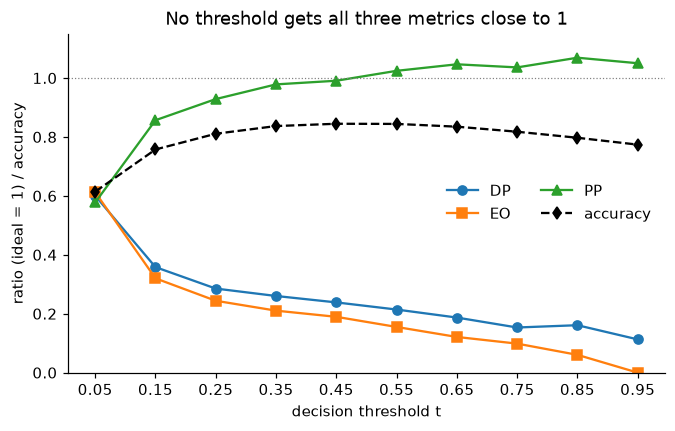

In [38]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(fair.index, fair["DP"], "o-", label="DP")
ax.plot(fair.index, fair["EO"], "s-", label="EO")
ax.plot(fair.index, fair["PP"], "^-", label="PP")
ax.plot(fair.index, fair["accuracy"], "d--", color="black", label="accuracy")
ax.axhline(1, color="grey", lw=0.8, ls=":")
ax.set_xticks(fair.index)
ax.set_xlabel("decision threshold t")
ax.set_ylabel("ratio (ideal = 1) / accuracy")
ax.set_ylim(0, 1.15)
ax.set_title("No threshold gets all three metrics close to 1")
ax.legend(frameon=False, ncol=2, loc="center right")
fig.savefig(FIG_DIR / "fig6_metrics_vs_threshold.png")
plt.show()

In [39]:
# quantifying the trade-off: "if DP improves from X to Y (Z% gain), EO drops from A to B (W% loss), cost = W/Z"
def tradeoff(t_from, t_to, gain_metric="DP", loss_metric="EO"):
    a, b = fair.loc[t_from], fair.loc[t_to]
    gain = (b[gain_metric] - a[gain_metric]) / a[gain_metric] * 100
    loss = (a[loss_metric] - b[loss_metric]) / a[loss_metric] * 100
    return {"from": t_from, "to": t_to, f"{gain_metric}_from": a[gain_metric], f"{gain_metric}_to": b[gain_metric],
            f"{loss_metric}_from": a[loss_metric], f"{loss_metric}_to": b[loss_metric],
            "gain_pct": gain, "loss_pct": loss, "cost": loss / gain}


# every pair of neighbouring thresholds where DP gets better while EO gets worse
pairs = []
for t1, t2 in zip(fair.index[:-1], fair.index[1:]):
    for a_, b_ in [(t1, t2), (t2, t1)]:
        if fair.loc[b_, "DP"] > fair.loc[a_, "DP"] and fair.loc[b_, "EO"] < fair.loc[a_, "EO"]:
            pairs.append(tradeoff(a_, b_))
print("DP-up / EO-down moves between neighbouring thresholds:")
print(pd.DataFrame(pairs).round(4), "\n")

# the main tension in this data: DP (and EO) against PP and accuracy
dp_pp = tradeoff(0.45, 0.15, "DP", "PP")
dp_pp_full = tradeoff(0.45, 0.05, "DP", "PP")
print("DP vs PP, t=0.45 -> 0.05:", {k: round(v, 4) for k, v in dp_pp_full.items()})
print("DP vs PP, t=0.45 -> 0.15:", {k: round(v, 4) for k, v in dp_pp.items()})
print("EO over the same move:", round(fair.loc[0.45, "EO"], 4), "->", round(fair.loc[0.15, "EO"], 4))
print("accuracy over the same move:", round(fair.loc[0.45, "accuracy"], 4), "->", round(fair.loc[0.15, "accuracy"], 4))

pd.DataFrame(pairs + [dp_pp]).round(6).to_csv(TAB_DIR / "part2_4_tradeoffs.csv", index=False)
key["tradeoff_dp_eo"] = [{k: round(float(v), 4) for k, v in p.items()} for p in pairs]
key["tradeoff_dp_pp"] = {k: round(float(v), 4) for k, v in dp_pp.items()}
key["tradeoff_dp_pp_full"] = {k: round(float(v), 4) for k, v in dp_pp_full.items()}
key["best_dp_threshold"] = float(fair["DP"].idxmax())
key["best_eo_threshold"] = float(fair["EO"].idxmax())
key["best_pp_threshold"] = float((fair["PP"] - 1).abs().idxmin())
key["best_acc_threshold"] = float(fair["accuracy"].idxmax())
print("closest to 1 -> DP at", key["best_dp_threshold"], "| EO at", key["best_eo_threshold"],
      "| PP at", key["best_pp_threshold"], "| best accuracy at", key["best_acc_threshold"])

DP-up / EO-down moves between neighbouring thresholds:
   from    to  DP_from  DP_to  EO_from   EO_to  gain_pct  loss_pct    cost
0  0.75  0.85   0.1532  0.161   0.0985  0.0604    5.0669    38.664  7.6307 

DP vs PP, t=0.45 -> 0.05: {'from': 0.45, 'to': 0.05, 'DP_from': np.float64(0.2384), 'DP_to': np.float64(0.6003), 'PP_from': np.float64(0.9908), 'PP_to': np.float64(0.5777), 'gain_pct': np.float64(151.8064), 'loss_pct': np.float64(41.6938), 'cost': np.float64(0.2747)}
DP vs PP, t=0.45 -> 0.15: {'from': 0.45, 'to': 0.15, 'DP_from': np.float64(0.2384), 'DP_to': np.float64(0.3582), 'PP_from': np.float64(0.9908), 'PP_to': np.float64(0.8568), 'gain_pct': np.float64(50.2361), 'loss_pct': np.float64(13.5246), 'cost': np.float64(0.2692)}
EO over the same move: 0.1895 -> 0.3201
accuracy over the same move: 0.8448 -> 0.7575
closest to 1 -> DP at 0.05 | EO at 0.05 | PP at 0.45 | best accuracy at 0.45


## 7. Extra checks used in the written answers

### 7.1 Two real people from the test set (Question 6)

I look for a woman who really earns >50K and a married man who does not, with the same education, occupation, workclass and race and similar age and hours. Then I see what happens to each of them as the threshold moves.

In [40]:
women = test[(test.sex == "Female") & (test.y == 1) & (test.married == 0) & test.p.between(0.30, 0.45)]
men = test[(test.sex == "Male") & (test.y == 0) & (test.married == 1) & test.p.between(0.35, 0.55)]
candidates = []
for i, w in women.iterrows():
    match = men[(men.education_num == w.education_num) & (men.occupation == w.occupation) & (men.race == w.race)
                & (men.workclass == w.workclass)
                & ((men.age - w.age).abs() <= 3) & ((men.hours_per_week - w.hours_per_week).abs() <= 5)]
    for j, m in match.iterrows():
        candidates.append((abs(m.age - w.age) + abs(m.hours_per_week - w.hours_per_week), i, j))
candidates.sort()
_, wi, mi = candidates[0]
pair = test.loc[[wi, mi], ["sex", "age", "race", "marital_status", "education", "occupation", "workclass",
                           "hours_per_week", "capital_gain", "y", "p"]].copy()
pair["capital_gain_dollars"] = np.expm1(pair["capital_gain"]).round(0)
for t in [0.25, 0.35, 0.45, 0.55]:
    pair[f"flag_at_{t}"] = (pair["p"] >= t).astype(int)
pair.to_csv(TAB_DIR / "q6_example_pair.csv")
print(len(candidates), "matching pairs found; using the closest one")
pair.T

8 matching pairs found; using the closest one


,2713,24246
sex,Female,Male
age,39,38
race,White,White
marital_status,Div-Sep,Married
education,Some-college,Some-college
occupation,Exec-managerial,Exec-managerial
workclass,Private,Private
hours_per_week,40,40
capital_gain,9.06126,0.0
y,1,0


In [41]:
key["pair_woman"] = {k: (v.item() if hasattr(v, "item") else v) for k, v in test.loc[wi, ["age", "education", "occupation", "hours_per_week", "marital_status", "y", "p"]].items()}
key["pair_woman"]["capital_gain_dollars"] = float(np.expm1(test.loc[wi, "capital_gain"]).round(0))
key["pair_man"] = {k: (v.item() if hasattr(v, "item") else v) for k, v in test.loc[mi, ["age", "education", "occupation", "hours_per_week", "marital_status", "y", "p"]].items()}
key["pair_man"]["capital_gain_dollars"] = float(np.expm1(test.loc[mi, "capital_gain"]).round(0))
key["pair_index"] = [int(wi), int(mi)]
print(key["pair_woman"])
print(key["pair_man"])

{'age': 39, 'education': 'Some-college', 'occupation': 'Exec-managerial', 'hours_per_week': 40, 'marital_status': 'Div-Sep', 'y': 1, 'p': 0.3840218498044245, 'capital_gain_dollars': 8614.0}
{'age': 38, 'education': 'Some-college', 'occupation': 'Exec-managerial', 'hours_per_week': 40, 'marital_status': 'Married', 'y': 0, 'p': 0.4710726463842277, 'capital_gain_dollars': 0.0}


### 7.2 Residual check against a column the model never saw (Question 4)

One practical way to spot a hidden confound is to take a variable that was left out of the model and check whether the residuals (actual minus predicted) differ systematically across its categories. A well-specified model should leave average residuals near zero everywhere. Here I use `relationship`, which I removed during preprocessing.

In [42]:
test["resid"] = test["y"] - test["p"]
resid_tab = test.groupby("relationship").agg(n=("resid", "size"), mean_actual=("y", "mean"),
                                              mean_pred=("p", "mean"), mean_resid=("resid", "mean"),
                                              se=("resid", "sem"))
resid_tab["t_stat"] = resid_tab["mean_resid"] / resid_tab["se"]
resid_tab.round(6).to_csv(TAB_DIR / "q4_residuals_by_relationship.csv")
print(resid_tab.round(4))

# same check after adding the sex x married interaction from Section 3
X_test_int = X_test.copy()
X_test_int["male_x_married"] = X_test_int["sex_Male"] * X_test_int["marital_status_Married"]
test["resid_int"] = test["y"] - m_int.predict(X_test_int)
print("\nwith the interaction term:")
resid_int_tab = test.groupby("relationship")["resid_int"].agg(["mean", "sem"])
resid_int_tab["t_stat"] = resid_int_tab["mean"] / resid_int_tab["sem"]
print(resid_int_tab.round(4))
key["resid_t_after_int"] = resid_int_tab["t_stat"].round(2).to_dict()
key["resid_wife"] = round(resid_tab.loc["Wife", "mean_resid"], 4)
key["resid_wife_t"] = round(resid_tab.loc["Wife", "t_stat"], 2)
key["resid_wife_n"] = int(resid_tab.loc["Wife", "n"])
key["resid_wife_actual"] = round(resid_tab.loc["Wife", "mean_actual"], 4)
key["resid_wife_pred"] = round(resid_tab.loc["Wife", "mean_pred"], 4)
key["resid_husband"] = round(resid_tab.loc["Husband", "mean_resid"], 4)
key["resid_wife_after_int"] = round(test.loc[test.relationship == "Wife", "resid_int"].mean(), 4)

                   n  mean_actual  mean_pred  mean_resid      se  t_stat
relationship                                                            
Husband         5857       0.4550     0.4581     -0.0031  0.0056 -0.5546
Not-in-family   3843       0.0968     0.0889      0.0079  0.0042  1.8765
Other-relative   468       0.0342     0.0635     -0.0293  0.0074 -3.9392
Own-child       2246       0.0165     0.0274     -0.0110  0.0024 -4.4772
Unmarried       1509       0.0596     0.0749     -0.0153  0.0053 -2.8867
Wife             714       0.4622     0.3782      0.0840  0.0164  5.1231

with the interaction term:
                  mean     sem  t_stat
relationship                          
Husband         0.0066  0.0056  1.1970
Not-in-family   0.0057  0.0042  1.3617
Other-relative -0.0312  0.0075 -4.1845
Own-child      -0.0112  0.0024 -4.5990
Unmarried      -0.0084  0.0052 -1.6159
Wife            0.0063  0.0164  0.3819


### 7.3 Accuracy by group at the default threshold (Part 4)

In [43]:
by_sex = test.groupby("sex").apply(lambda d: pd.Series({
    "n": len(d), "base_rate": d.y.mean(),
    "accuracy_at_0.5": ((d.p >= 0.5) == d.y.astype(bool)).mean(),
    "TPR_at_0.5": (d.p[d.y == 1] >= 0.5).mean(),
    "FPR_at_0.5": (d.p[d.y == 0] >= 0.5).mean(),
}), include_groups=False)
by_sex.round(6).to_csv(TAB_DIR / "part4_accuracy_by_sex.csv")
print(by_sex.round(4))
key["acc_by_sex"] = {s: {k: round(float(v), 4) for k, v in r.items()} for s, r in by_sex.iterrows()}

             n  base_rate  accuracy_at_0.5  TPR_at_0.5  FPR_at_0.5
sex                                                               
Female  4936.0     0.1090           0.9184      0.4015      0.0184
Male    9701.0     0.3064           0.8096      0.6184      0.1060


### Saving the headline numbers

In [44]:
def to_builtin(o):
    if isinstance(o, dict):
        return {str(k): to_builtin(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [to_builtin(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    return o


with open("outputs/key_numbers.json", "w") as f:
    json.dump(to_builtin(key), f, indent=2)
print("saved", len(key), "entries to outputs/key_numbers.json")

saved 188 entries to outputs/key_numbers.json
